# Проект "Предсказание оттока клиентов для компании "Теледом""

Цель проекта: построить модель для прогноза оттока клиентов со значением метрики ROC-AUC на тестовой выборке не менее 0.85.

## Описание данных

Датасет состоит из четырёх таблиц, объединённых по customerID:
- personal (демография) — 7 043 строк; ключевые поля: customerID, gender, SeniorCitizen, Partner, Dependents.
- contract (условия контракта) — 7 043 строк; ключевые поля: customerID, BeginDate, EndDate, Type (Contract), MonthlyCharges, TotalCharges, PaperlessBilling, PaymentMethod.
- internet (услуги интернета) — 5 517 строк; ключевые поля: customerID, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies.
- phone (услуги телефонии) — 6 361 строк; ключевые поля: customerID, MultipleLines.



In [1]:

import os
import pandas as pd
from sqlalchemy import create_engine
import math
import phik
import numpy as np
import matplotlib.pyplot as plt
from catboost import Pool
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer,  f1_score, r2_score, precision_score, recall_score, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import ttest_ind
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


RANDOM_STATE = 20226
test_size = 0.25

In [2]:
path_to_db = 'ds-plus-final.db'
engine = create_engine(f'sqlite:///{path_to_db}', echo=False) 

## Загрузка данных

In [3]:
contract = pd.read_sql('contract', con=engine)
personal = pd.read_sql('personal', con=engine)
internet = pd.read_sql('internet', con=engine)
phone = pd.read_sql('phone', con=engine)


display(contract.sample(5), personal.sample(5), internet.sample(5), phone.sample(5))

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
1073,0655-RBDUG,2019-03-01,No,Month-to-month,Yes,Bank transfer (automatic),98.05,1078.55
4007,1073-XXCZD,2015-07-01,No,Two year,No,Bank transfer (automatic),25.7,1413.5
2015,5155-AZQPB,2017-10-01,No,Month-to-month,No,Mailed check,49.9,1397.2
6355,1936-UAFEH,2014-06-01,No,Two year,No,Credit card (automatic),110.25,7497.0
3937,5712-VBOXD,2019-10-01,No,Month-to-month,Yes,Credit card (automatic),20.15,88.66


,customerID,gender,SeniorCitizen,Partner,Dependents
5307,1941-HOSAM,Male,0,Yes,Yes
2807,1015-JPFYW,Male,0,No,Yes
6890,7470-DYNOE,Male,0,No,No
2724,4636-TVXVG,Male,0,Yes,Yes
4715,7508-DQAKK,Female,0,No,No


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
5415,1450-SKCVI,Fiber optic,No,Yes,No,No,No,No
5013,3865-ZYKAD,Fiber optic,Yes,Yes,No,No,No,No
812,1452-XRSJV,DSL,Yes,No,No,No,No,No
3413,1704-NRWYE,Fiber optic,No,No,No,No,Yes,No
5151,4701-AHWMW,DSL,No,No,Yes,Yes,Yes,Yes


,CustomerId,MultipleLines
6334,1685-BQULA,Yes
651,8434-VGEQQ,No
2658,0674-DGMAQ,Yes
1901,5934-TSSAU,No
4655,5980-NOPLP,Yes


### Вывод

Данные из базы загружены, все таблицы из условий проекта присутсвуют.

## EDA

In [4]:
def explore_data(df, discrete_columns=[]):
    """
    Функция для проведения исследовательского анализа данных
    
    Параметры:
    df (pandas.DataFrame): Входной датафрейм
    
    Возвращает:
    dict: Словарь с результатами анализа
    """
    
    results = {}
    
    # 1. Базовая информация о датафрейме
    print("="*50)
    print("ОБЩАЯ ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ")
    print("="*50)
    print(f"\nРазмер датафрейма: {df.shape}")
    print(f"\nИнформация о датафрейме:")
    df.info()
    
    # 2. Статистический анализ
    print("\n", "="*50)
    print("СТАТИСТИЧЕСКИЙ АНАЛИЗ")
    print("="*50)
    
    # Числовые колонки
    numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
    if len(numeric_columns) > 0:
        print("\nСтатистика по числовым колонкам:")
        display(df[numeric_columns].describe())
        
        # Корреляционная матрица
        if len(numeric_columns) != 1:
            plt.figure(figsize=(10, 8))
            sns.heatmap(df[numeric_columns].corr(method='kendall'), annot=True, cmap='coolwarm')
            plt.title('Корреляционная матрица')
            plt.show()
    
    # Категориальные колонки
    categorical_columns = df.select_dtypes(include=['object']).columns
    if len(categorical_columns) > 0:
        print("\nСтатистика по категориальным колонкам:")
        for col in categorical_columns:
            print(f"\nРаспределение значений в колонке {col}:")
            display(df[col].value_counts())
            print(f"Количество уникальных значений: {df[col].nunique()}")
    
    # 3. Пропущенные значения
    print("\n", "="*50)
    print("АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")
    print("="*50)
    missing_values = df.isnull().sum()
    missing_percent = (missing_values / len(df)) * 100
    missing_data = pd.concat([missing_values, missing_percent], axis=1)
    missing_data.columns = ['Количество пропусков', 'Процент пропусков']
    print("\nИнформация о пропущенных значениях:")
    display(missing_data[missing_data['Количество пропусков'] > 0])
    
    # 4. Визуализация распределений
    print("\n", "="*50)
    print("ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ")
    print("="*50)
    
        
    for col in numeric_columns:
        if col not in discrete_columns:
            plt.figure(figsize=(10, 4))
        
            # Гистограмма
            plt.subplot(1, 2, 1)
            sns.histplot(data=df, x=col, kde=True, bins=int((math.log(len(col), 2) + 1)))
            plt.title(f'Распределение {col}')

            # Box plot
            plt.subplot(1, 2, 2)
            sns.violinplot(data=df, y=col)
            plt.title(f'Box plot {col}')

            plt.tight_layout()
            plt.show()

    for col in discrete_columns:
        plt.figure(figsize=(8, 4))
        
        # Countplot
        sns.countplot(data=df, x=col, palette='pastel')
        plt.title(f'Countplot for {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        
        plt.xticks(rotation=45)  # Поворот меток оси X, если значения длинные
        plt.tight_layout()
        plt.show()
    
    return results



In [5]:
for i in [contract, personal, internet, phone]:
    print(i.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   BeginDate         7043 non-null   object
 2   EndDate           7043 non-null   object
 3   Type              7043 non-null   object
 4   PaperlessBilling  7043 non-null   object
 5   PaymentMethod     7043 non-null   object
 6   MonthlyCharges    7043 non-null   object
 7   TotalCharges      7043 non-null   object
dtypes: object(8)
memory usage: 440.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   object
 3   Partner        7043 non-null   object
 4   Dependents     704

In [6]:
phone.rename(columns={'CustomerId': 'customerID'}, inplace=True)

contract['MonthlyCharges'] = contract['MonthlyCharges'].astype('float')
contract['TotalCharges'] = pd.to_numeric(
    contract['TotalCharges'],
    errors='coerce'
)

contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])
contract['EndDate'] = pd.to_datetime(
    contract['EndDate'],
    errors='coerce'
)

contract['EndDate'].isna().value_counts()

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/881719481.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  contract['EndDate'] = pd.to_datetime(


EndDate
True     5942
False    1101
Name: count, dtype: int64

видим что количество ушедших пользователей значительно выше

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ

Размер датафрейма: (7043, 4)

Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   gender         7043 non-null   object
 1   SeniorCitizen  7043 non-null   object
 2   Partner        7043 non-null   object
 3   Dependents     7043 non-null   object
dtypes: object(4)
memory usage: 220.2+ KB

СТАТИСТИЧЕСКИЙ АНАЛИЗ

Статистика по категориальным колонкам:

Распределение значений в колонке gender:


gender
Male      3555
Female    3488
Name: count, dtype: int64

Количество уникальных значений: 2

Распределение значений в колонке SeniorCitizen:


SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Количество уникальных значений: 2

Распределение значений в колонке Partner:


...

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Количество уникальных значений: 2

АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

Информация о пропущенных значениях:


,Количество пропусков,Процент пропусков



ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ


/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


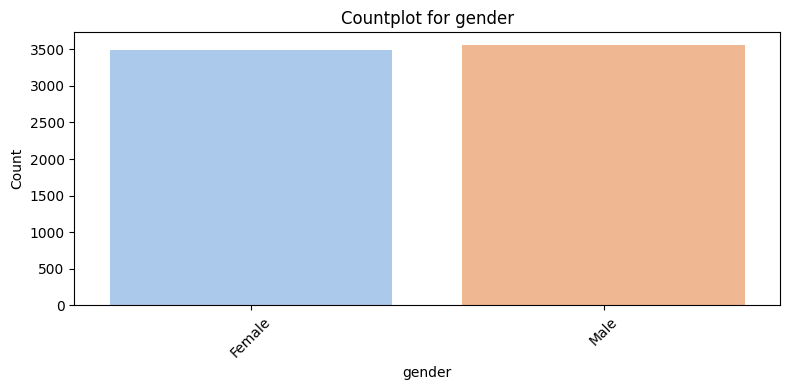

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


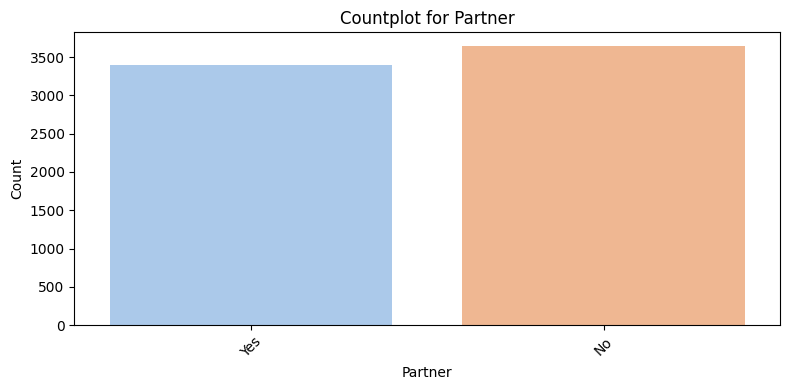

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


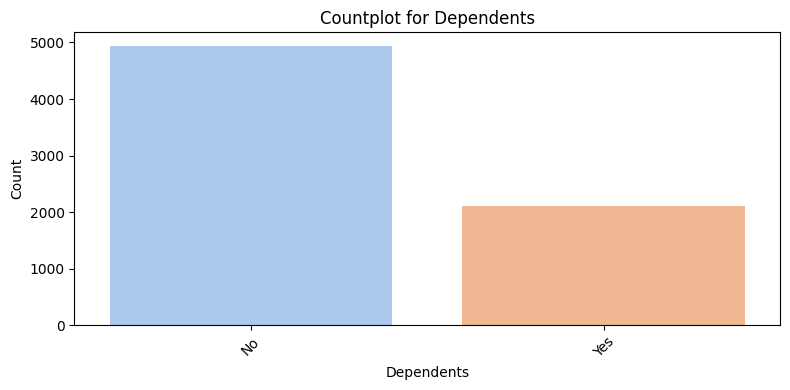

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


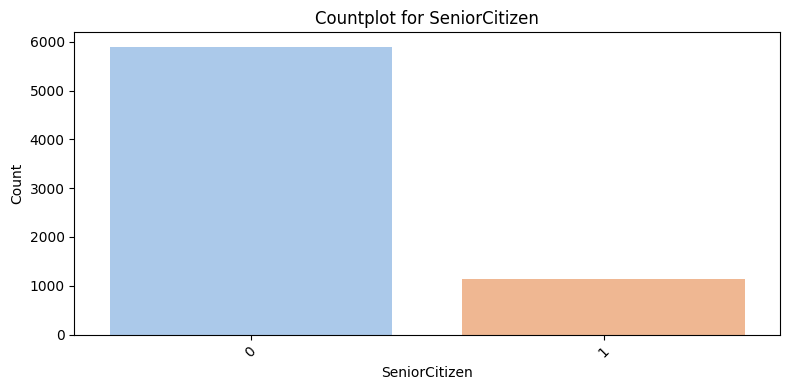

{}

In [7]:
explore_data(personal.drop(columns=['customerID']), discrete_columns=['gender', 'Partner', 'Dependents', 'SeniorCitizen'])

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ

Размер датафрейма: (7043, 7)

Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   BeginDate         7043 non-null   datetime64[ns]
 1   EndDate           1101 non-null   datetime64[ns]
 2   Type              7043 non-null   object        
 3   PaperlessBilling  7043 non-null   object        
 4   PaymentMethod     7043 non-null   object        
 5   MonthlyCharges    7043 non-null   float64       
 6   TotalCharges      7032 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(3)
memory usage: 385.3+ KB

СТАТИСТИЧЕСКИЙ АНАЛИЗ

Статистика по числовым колонкам:


,MonthlyCharges,TotalCharges
count,7043.000000,7032.000000
mean,64.761692,2118.621822
std,30.090047,2112.736199
min,18.250000,19.050000
25%,35.500000,439.745000
50%,70.350000,1345.275000
75%,89.850000,3239.317500
max,118.750000,9221.380000


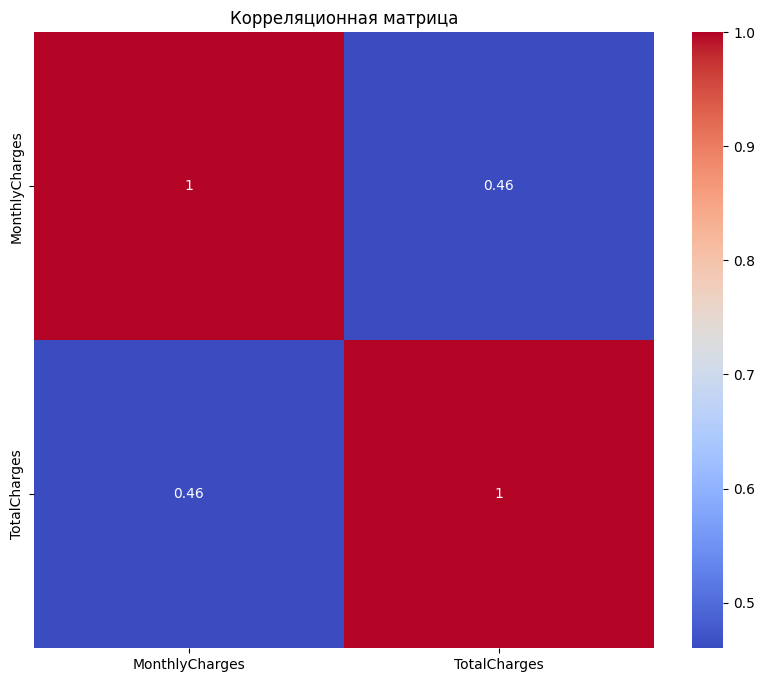


Статистика по категориальным колонкам:

Распределение значений в колонке Type:


Type
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Количество уникальных значений: 3

Распределение значений в колонке PaperlessBilling:


PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

Количество уникальных значений: 2

Распределение значений в колонке PaymentMethod:


PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

Количество уникальных значений: 4

АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

Информация о пропущенных значениях:


,Количество пропусков,Процент пропусков
EndDate,5942,84.367457
TotalCharges,11,0.156183



ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ


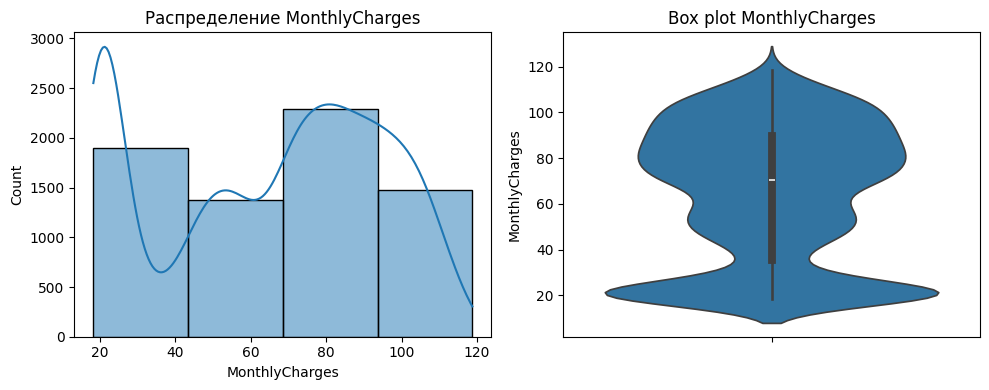

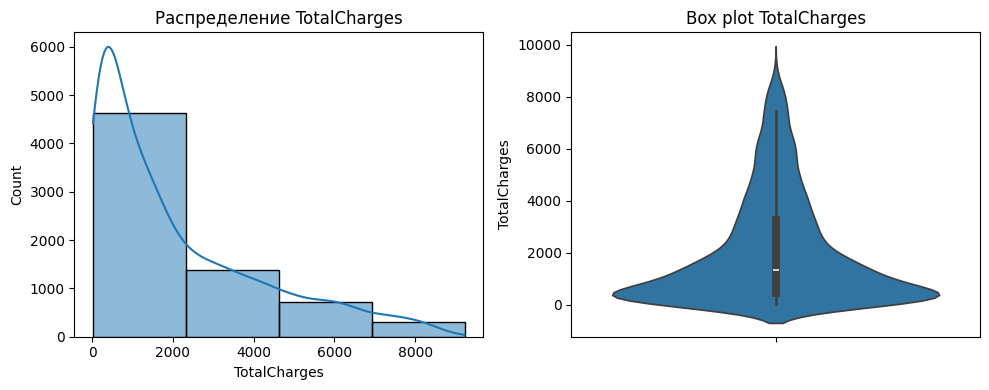

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


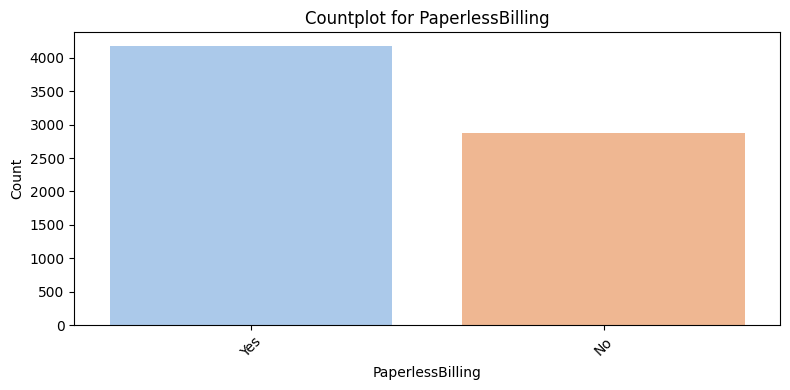

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


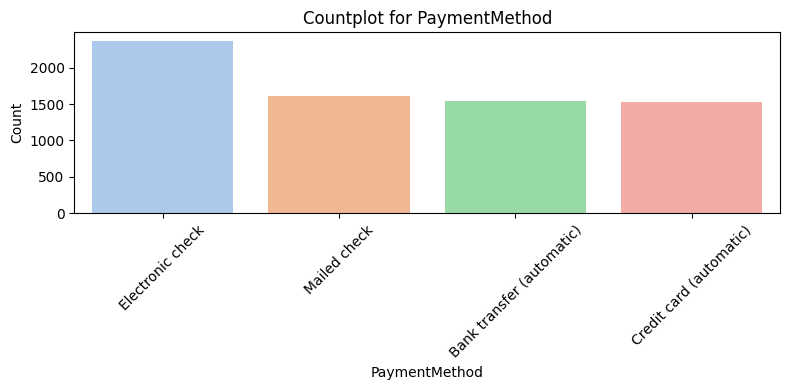

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


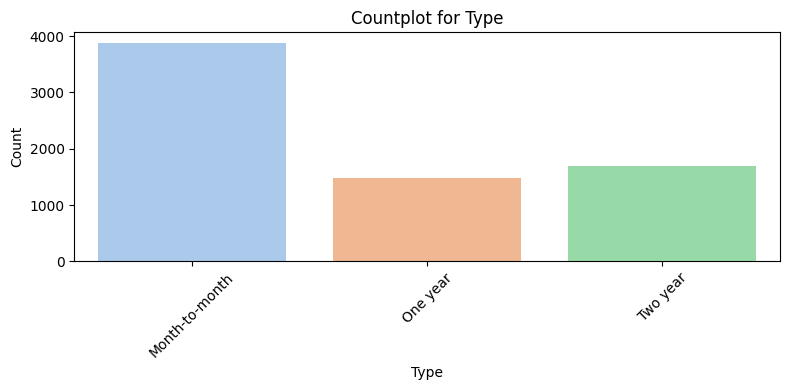

{}

In [8]:
explore_data(contract.drop(columns=['customerID']), discrete_columns=['PaperlessBilling', 'PaymentMethod', 'Type'])

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ

Размер датафрейма: (5517, 7)

Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   InternetService   5517 non-null   object
 1   OnlineSecurity    5517 non-null   object
 2   OnlineBackup      5517 non-null   object
 3   DeviceProtection  5517 non-null   object
 4   TechSupport       5517 non-null   object
 5   StreamingTV       5517 non-null   object
 6   StreamingMovies   5517 non-null   object
dtypes: object(7)
memory usage: 301.8+ KB

СТАТИСТИЧЕСКИЙ АНАЛИЗ

Статистика по категориальным колонкам:

Распределение значений в колонке InternetService:


InternetService
Fiber optic    3096
DSL            2421
Name: count, dtype: int64

Количество уникальных значений: 2

Распределение значений в колонке OnlineSecurity:


OnlineSecurity
No     3498
Yes    2019
Name: count, dtype: int64

Количество уникальных значений: 2

Распределение значений в колонке OnlineBackup:


...

StreamingMovies
No     2785
Yes    2732
Name: count, dtype: int64

Количество уникальных значений: 2

АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

Информация о пропущенных значениях:


,Количество пропусков,Процент пропусков


/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')



ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ


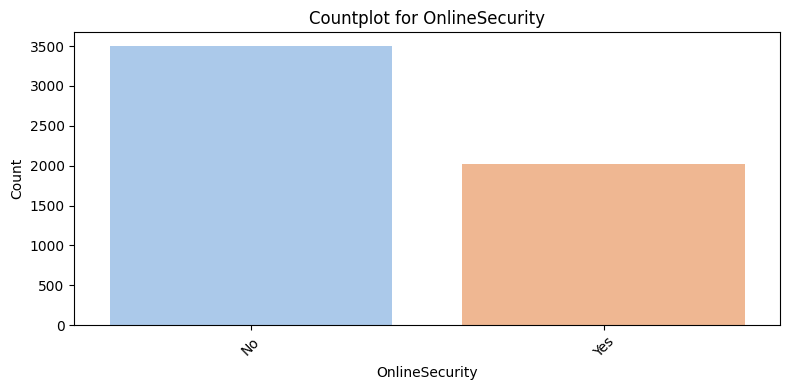

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


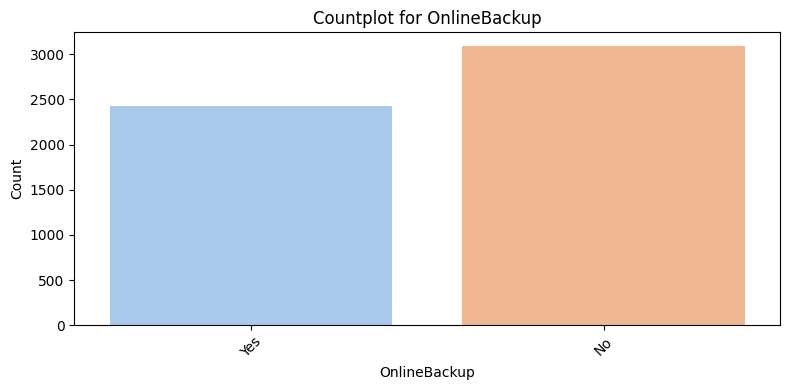

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


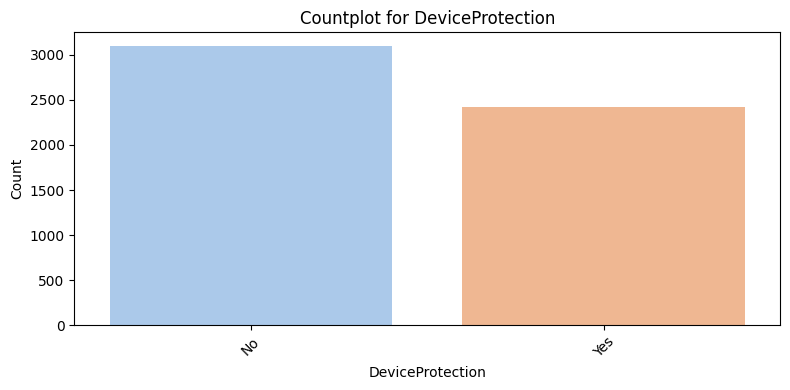

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


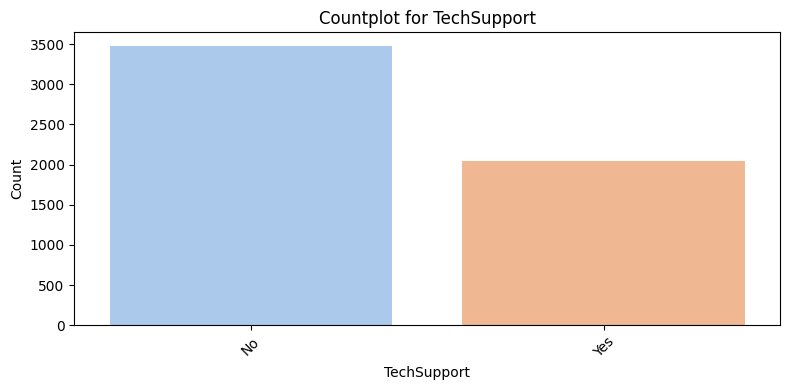

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


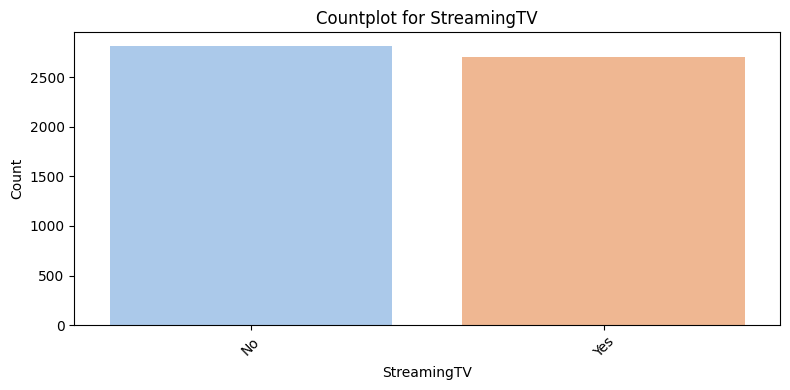

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


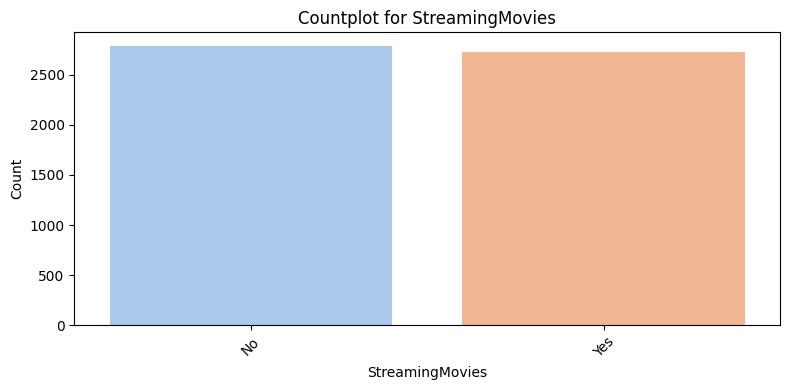

{}

In [9]:
explore_data(internet.drop(columns=['customerID']), discrete_columns=['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'])

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ

Размер датафрейма: (6361, 1)

Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MultipleLines  6361 non-null   object
dtypes: object(1)
memory usage: 49.8+ KB

СТАТИСТИЧЕСКИЙ АНАЛИЗ

Статистика по категориальным колонкам:

Распределение значений в колонке MultipleLines:


MultipleLines
No     3390
Yes    2971
Name: count, dtype: int64

Количество уникальных значений: 2

АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

Информация о пропущенных значениях:


,Количество пропусков,Процент пропусков


/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')



ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ


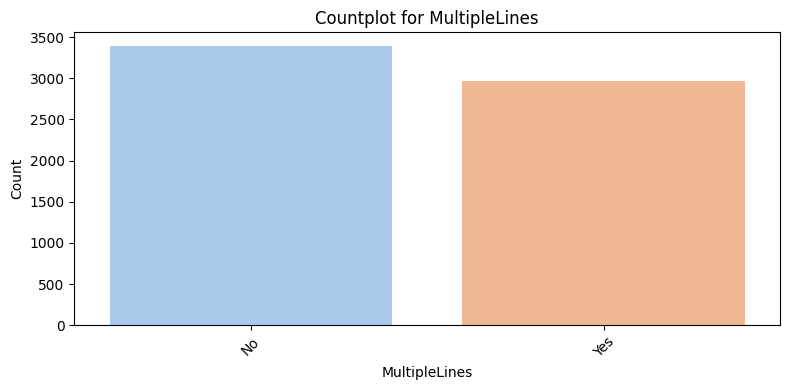

{}

In [10]:
explore_data(phone.drop(columns=['customerID']), discrete_columns=['MultipleLines'])

In [11]:
# internet['OnlineSecurity'] = internet['OnlineSecurity'].replace({'No internet service': 'No'})
# internet['OnlineBackup'] = internet['OnlineBackup'].replace({'No internet service': 'No'})
# internet['DeviceProtection'] = internet['DeviceProtection'].replace({'No internet service': 'No'})
# internet['TechSupport'] = internet['TechSupport'].replace({'No internet service': 'No'})
# internet['StreamingTV'] = internet['StreamingTV'].replace({'No internet service': 'No'})
# internet['StreamingMovies'] = internet['StreamingMovies'].replace({'No internet service': 'No'})

internet.dropna(inplace=True)

In [12]:
df = personal.merge(contract, on='customerID', how='left')
df = df.merge(internet, on='customerID', how='left')
df = df.merge(phone, on='customerID', how='left')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   gender            7043 non-null   object        
 2   SeniorCitizen     7043 non-null   object        
 3   Partner           7043 non-null   object        
 4   Dependents        7043 non-null   object        
 5   BeginDate         7043 non-null   datetime64[ns]
 6   EndDate           1101 non-null   datetime64[ns]
 7   Type              7043 non-null   object        
 8   PaperlessBilling  7043 non-null   object        
 9   PaymentMethod     7043 non-null   object        
 10  MonthlyCharges    7043 non-null   float64       
 11  TotalCharges      7032 non-null   float64       
 12  InternetService   5517 non-null   object        
 13  OnlineSecurity    5517 non-null   object        
 14  OnlineBackup      5517 n

In [13]:
df['customerID'].nunique(), df.shape #проверяем, что после объединения не потеряли клиентов

(7043, (7043, 20))

In [14]:
df['Churn'] = df['EndDate'].notna().astype('int') # 1 - ушел, 0 - остался

In [15]:
today = pd.Timestamp('2020-02-01')

df['ContractDurationDays'] = (df['EndDate'].fillna(today) - df['BeginDate']).dt.days


ОБЩАЯ ИНФОРМАЦИЯ О ДАТАФРЕЙМЕ

Размер датафрейма: (7043, 21)

Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   gender                7043 non-null   object        
 1   SeniorCitizen         7043 non-null   object        
 2   Partner               7043 non-null   object        
 3   Dependents            7043 non-null   object        
 4   BeginDate             7043 non-null   datetime64[ns]
 5   EndDate               1101 non-null   datetime64[ns]
 6   Type                  7043 non-null   object        
 7   PaperlessBilling      7043 non-null   object        
 8   PaymentMethod         7043 non-null   object        
 9   MonthlyCharges        7043 non-null   float64       
 10  TotalCharges          7032 non-null   float64       
 11  InternetService       5517 non-null   object   

,MonthlyCharges,TotalCharges,Churn,ContractDurationDays
count,7043.000000,7032.000000,7043.000000,7043.000000
mean,64.761692,2118.621822,0.156325,898.555729
std,30.090047,2112.736199,0.363189,683.130510
min,18.250000,19.050000,0.000000,0.000000
25%,35.500000,439.745000,0.000000,276.000000
50%,70.350000,1345.275000,0.000000,761.000000
75%,89.850000,3239.317500,0.000000,1461.000000
max,118.750000,9221.380000,1.000000,2314.000000


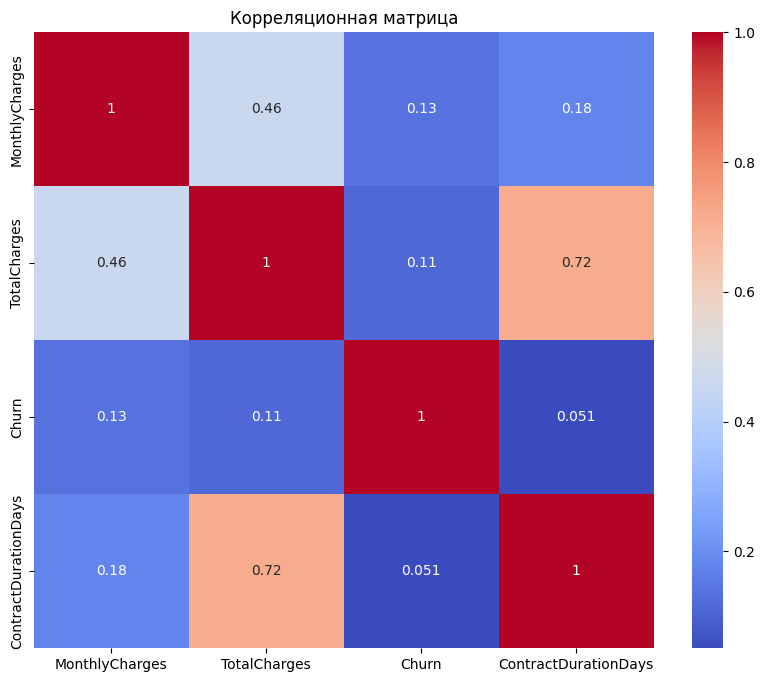


Статистика по категориальным колонкам:

Распределение значений в колонке gender:


gender
Male      3555
Female    3488
Name: count, dtype: int64

Количество уникальных значений: 2

Распределение значений в колонке SeniorCitizen:


SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Количество уникальных значений: 2

Распределение значений в колонке Partner:


...

Количество уникальных значений: 2

Распределение значений в колонке MultipleLines:


MultipleLines
No     3390
Yes    2971
Name: count, dtype: int64

Количество уникальных значений: 2

АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

Информация о пропущенных значениях:


,Количество пропусков,Процент пропусков
EndDate,5942,84.367457
TotalCharges,11,0.156183
InternetService,1526,21.666903
OnlineSecurity,1526,21.666903
OnlineBackup,1526,21.666903
DeviceProtection,1526,21.666903
TechSupport,1526,21.666903
StreamingTV,1526,21.666903
StreamingMovies,1526,21.666903
MultipleLines,682,9.683374



ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ


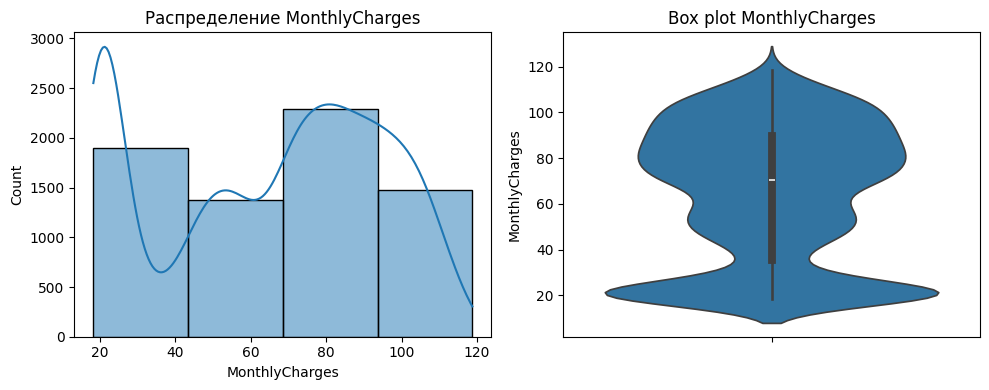

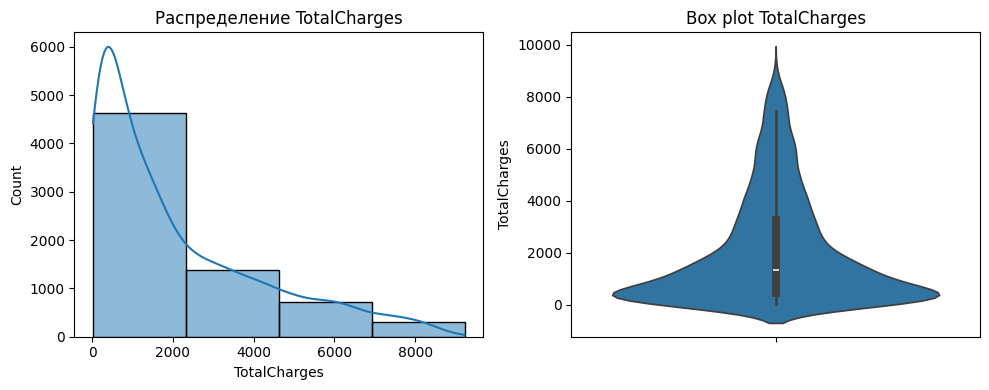

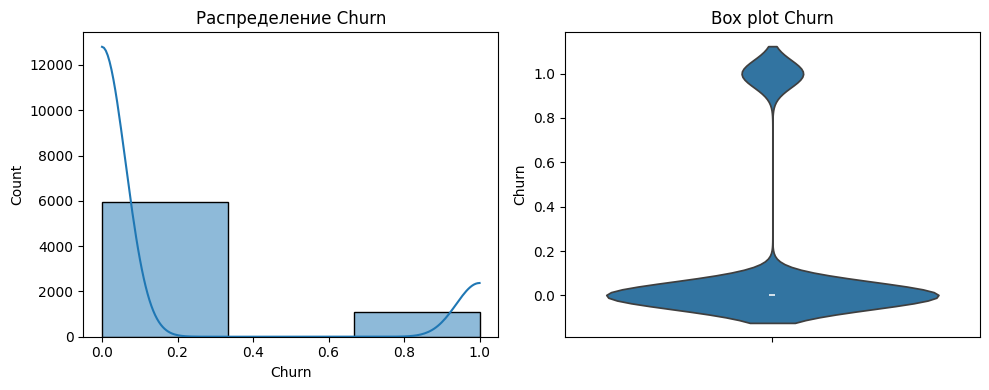

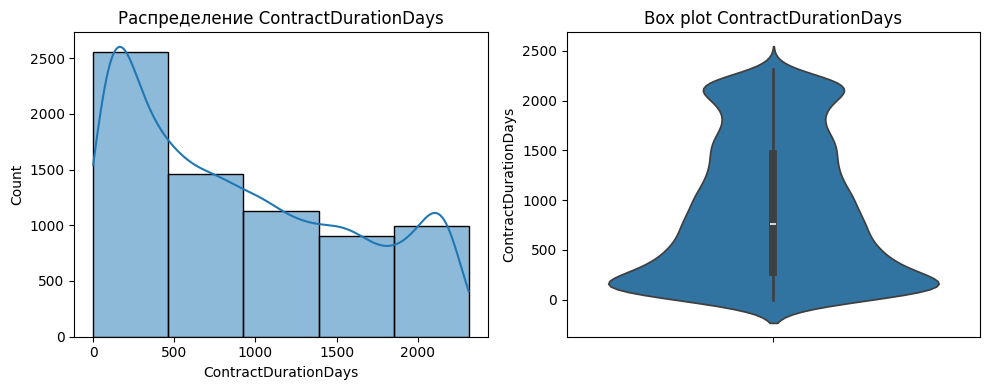

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


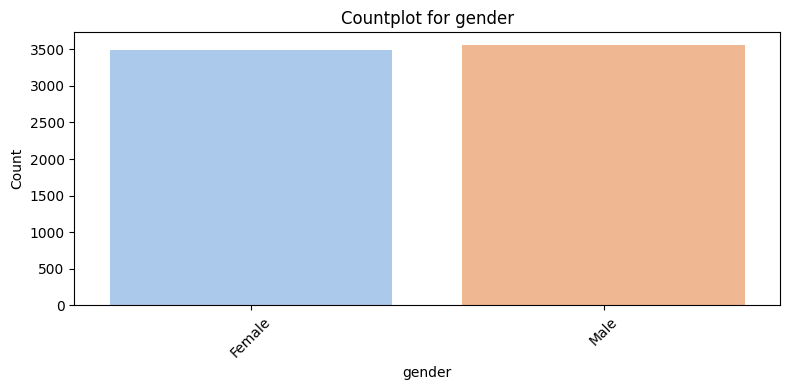

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


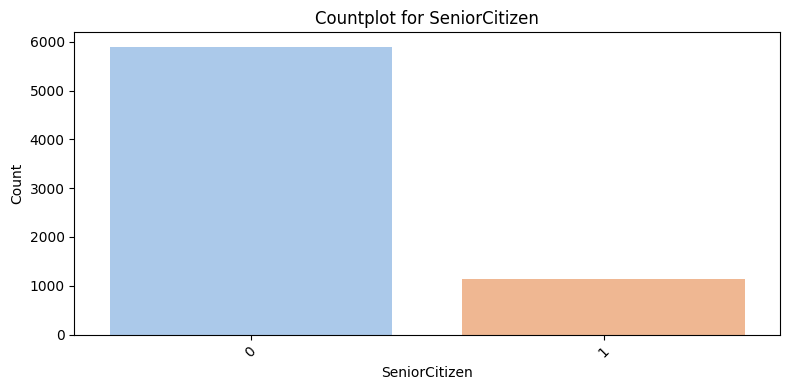

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


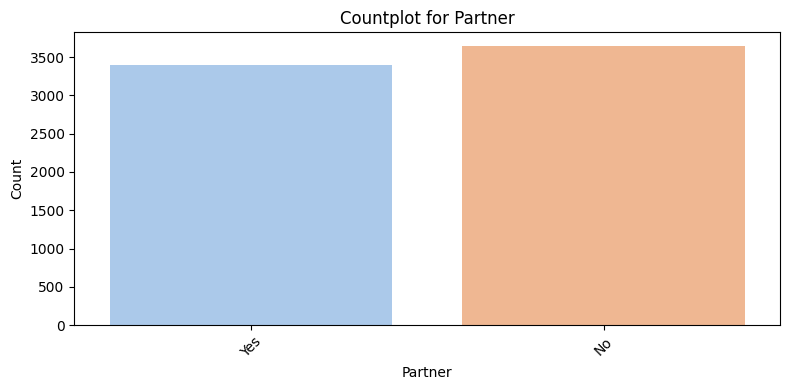

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


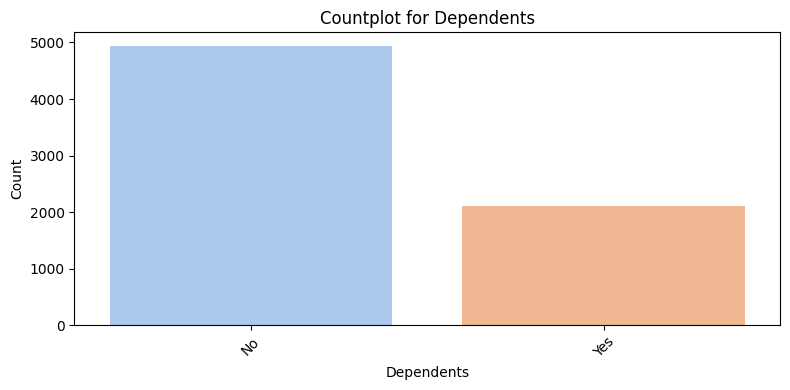

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


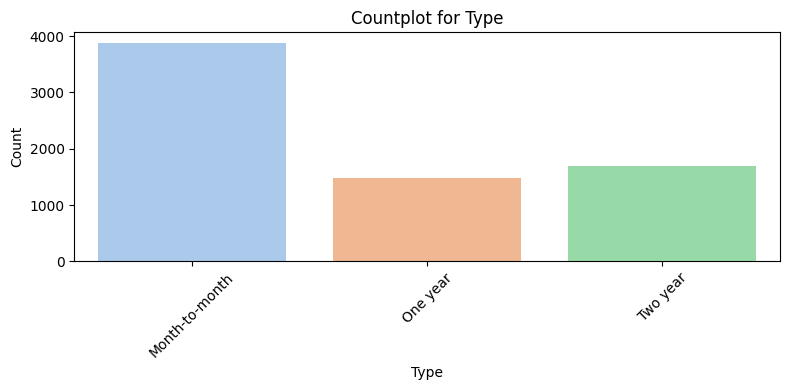

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


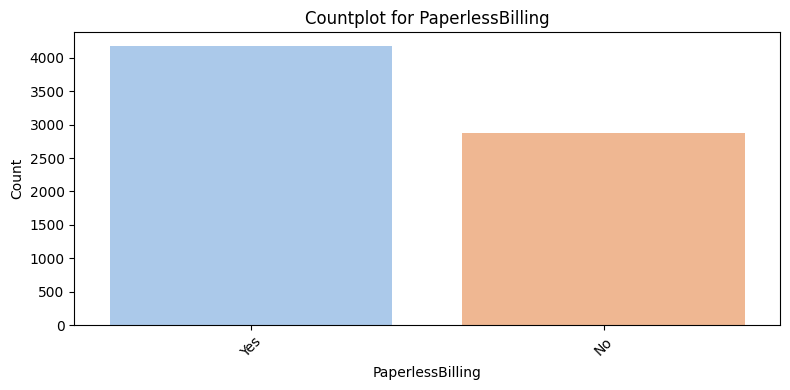

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


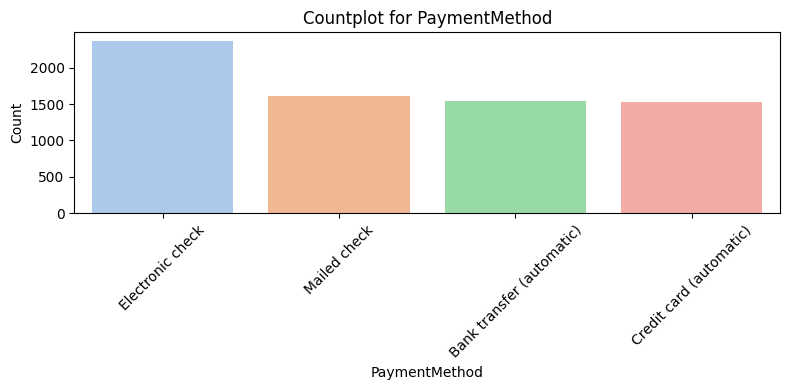

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


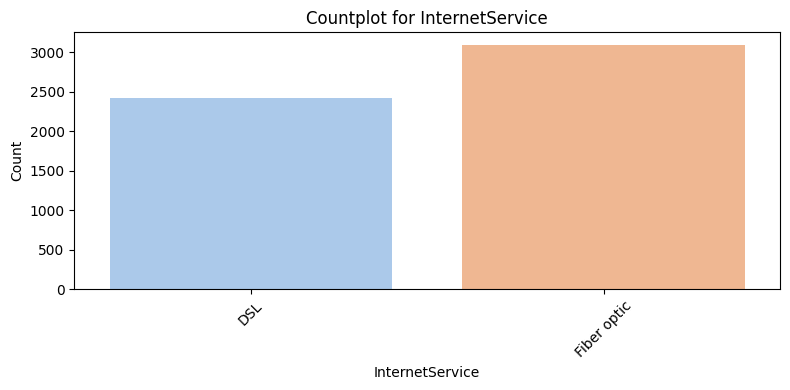

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


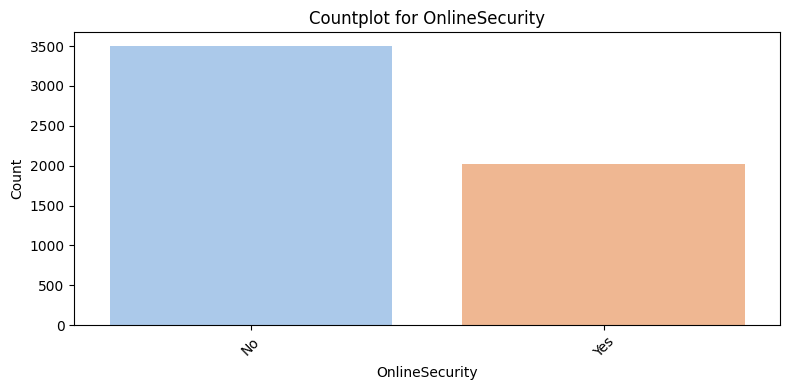

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


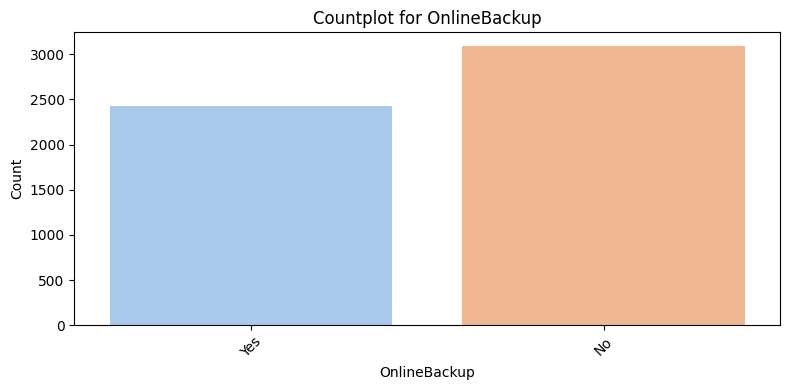

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


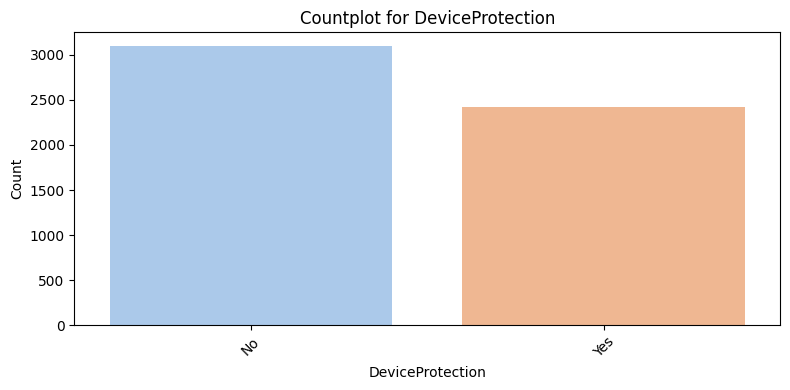

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


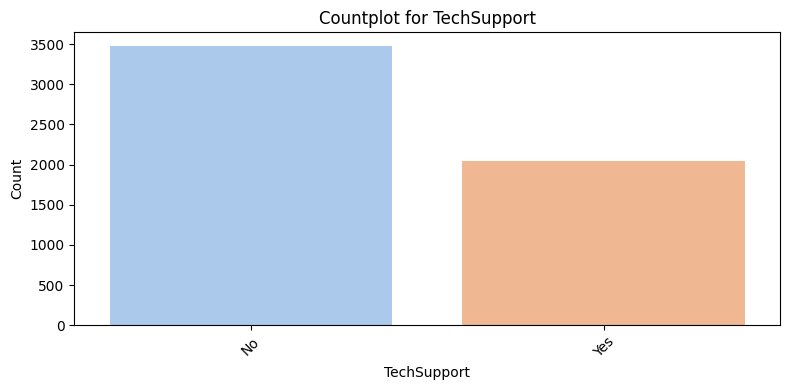

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


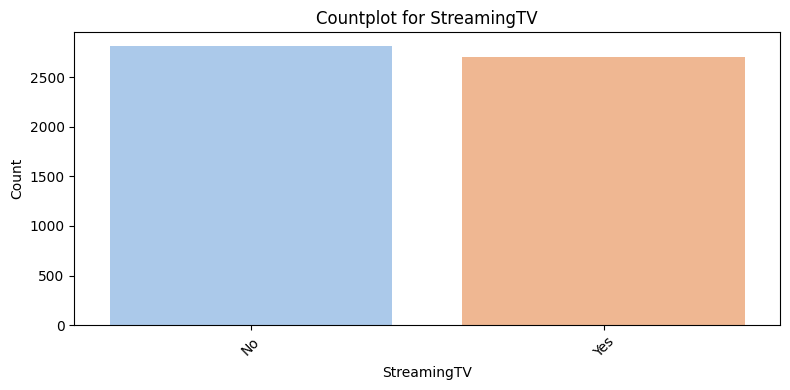

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


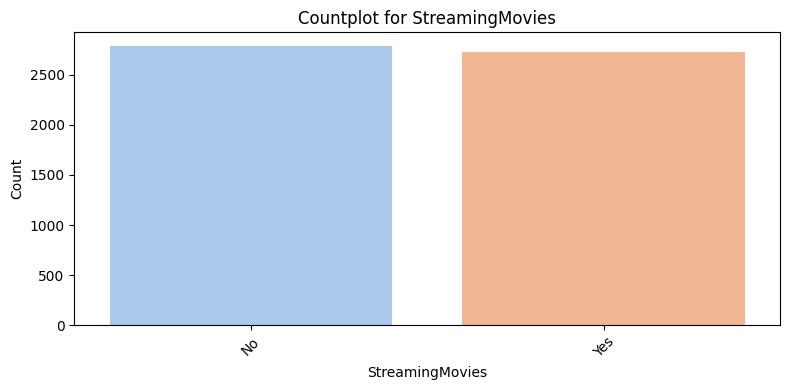

/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1114887030.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')


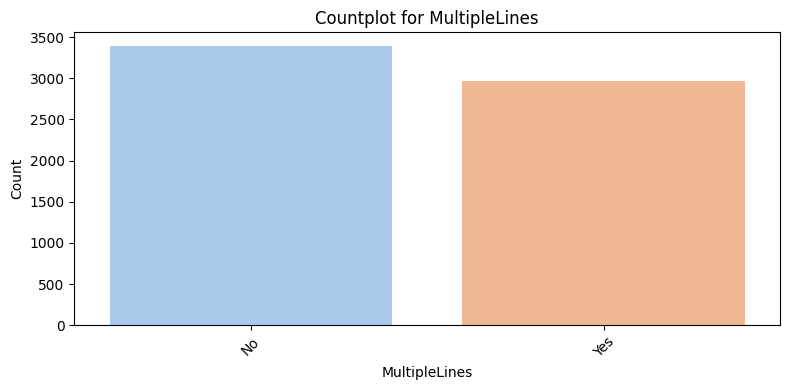

{}

In [16]:
df_no_id = df.drop(columns='customerID')

explore_data(
    df_no_id,
    discrete_columns=df_no_id.columns[df_no_id.dtypes == 'object'].tolist()
)

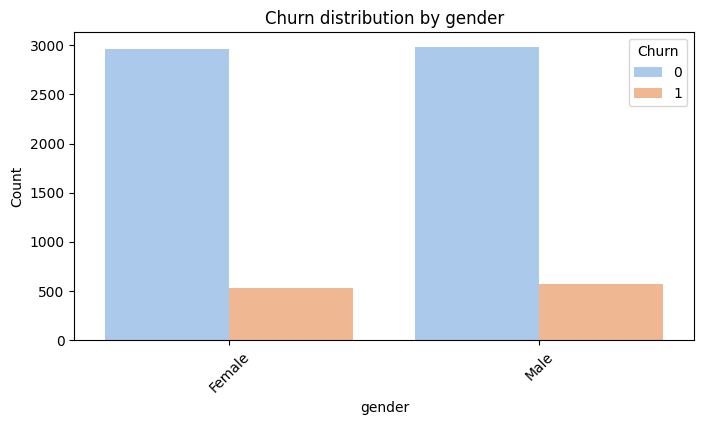

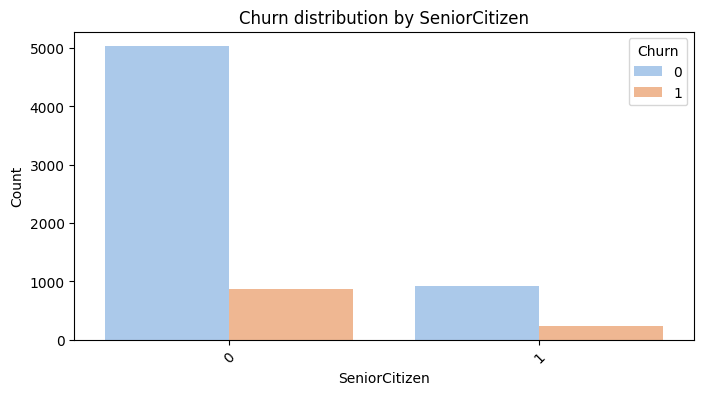

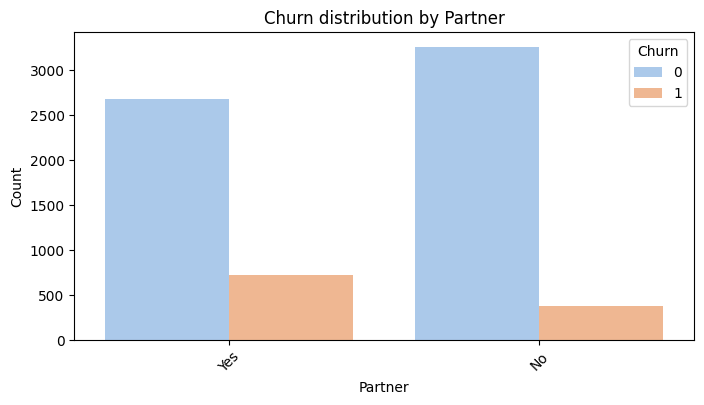

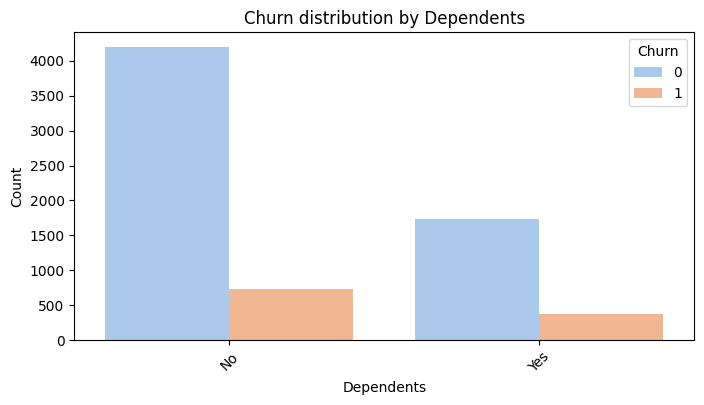

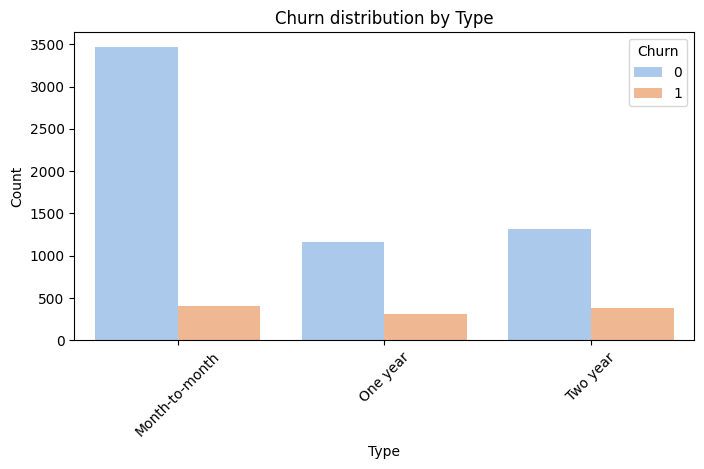

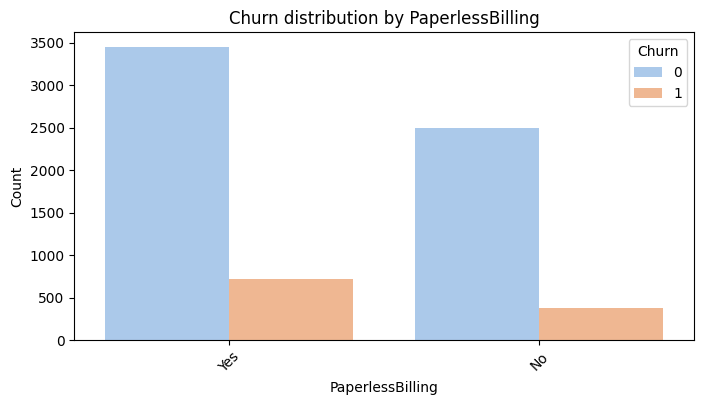

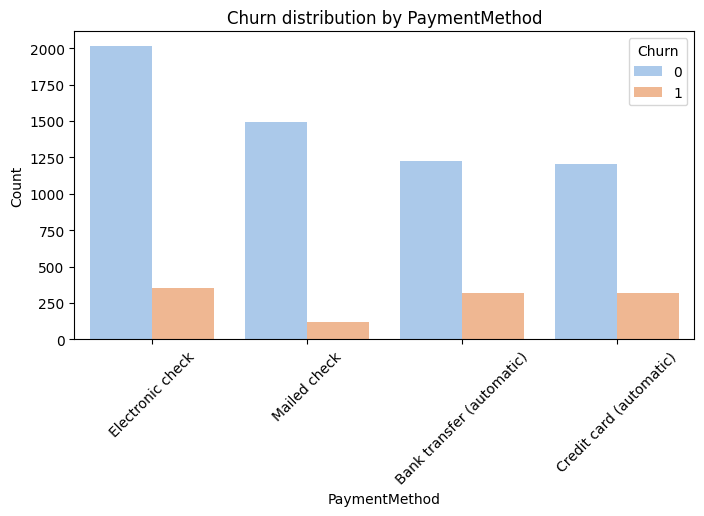

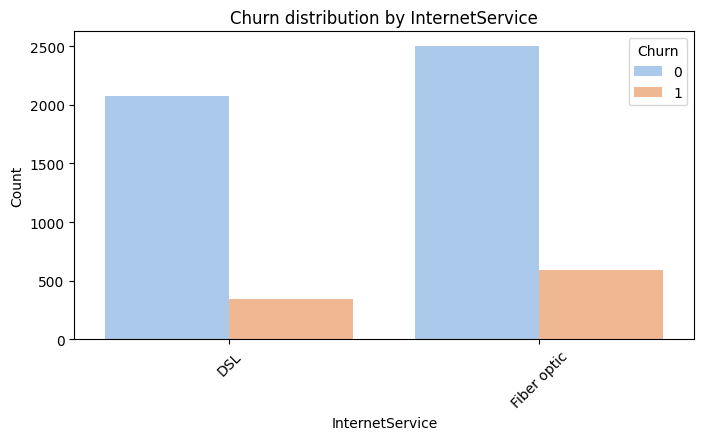

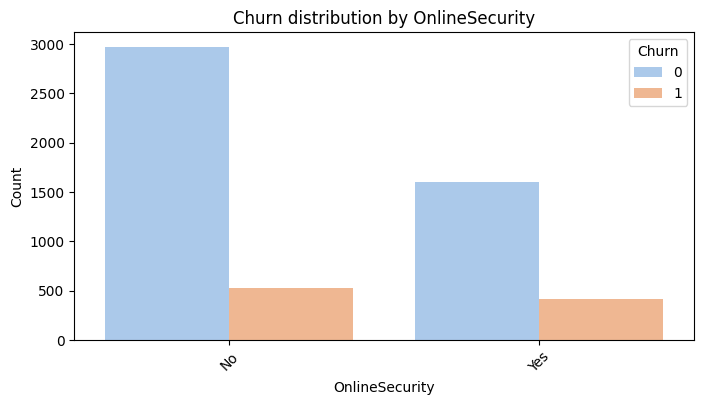

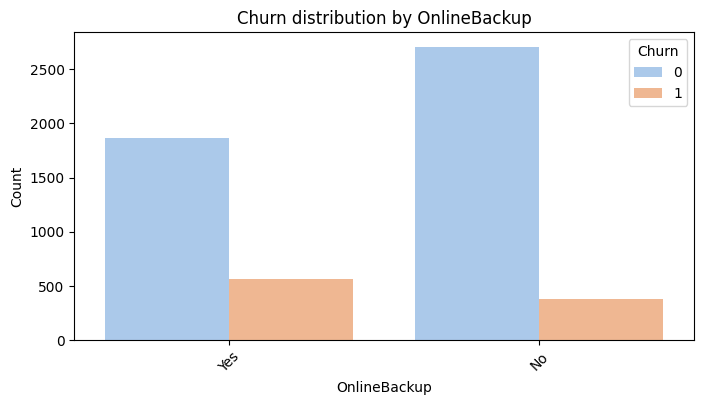

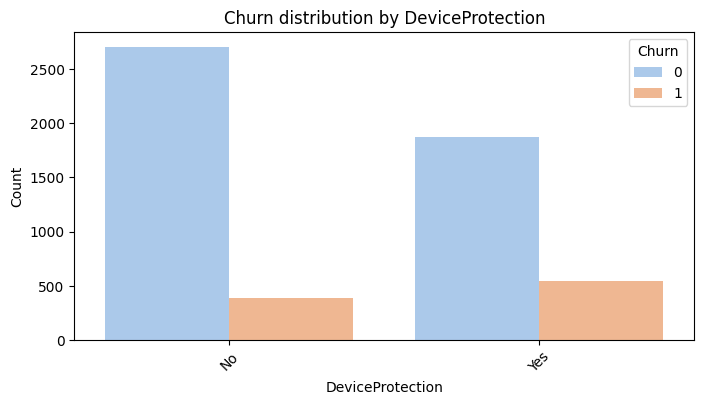

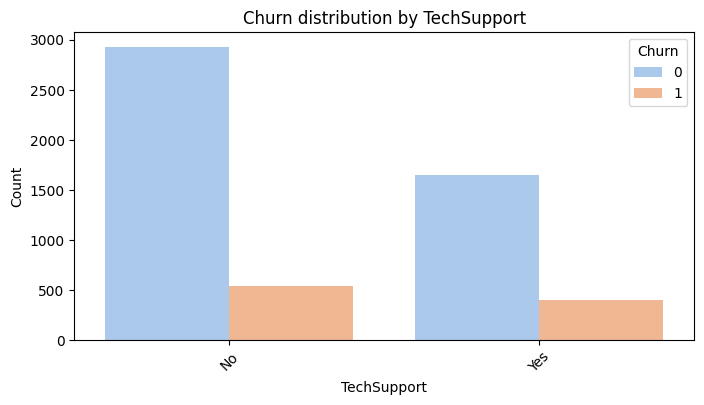

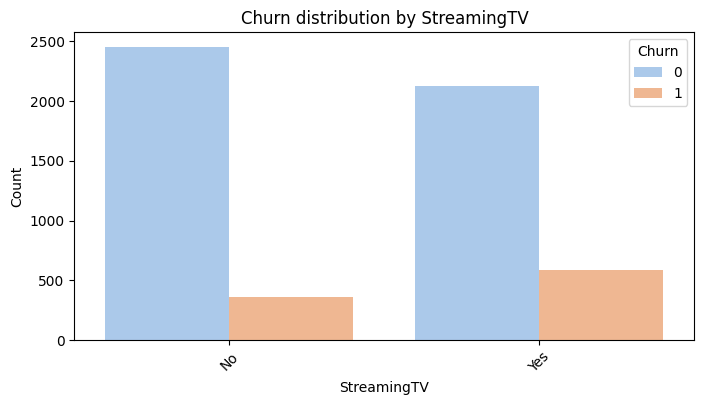

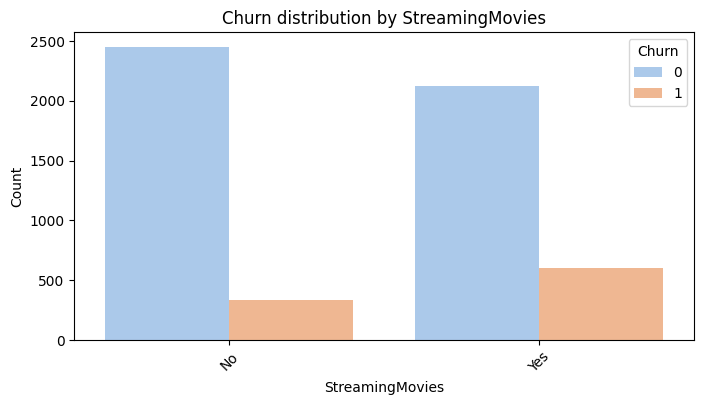

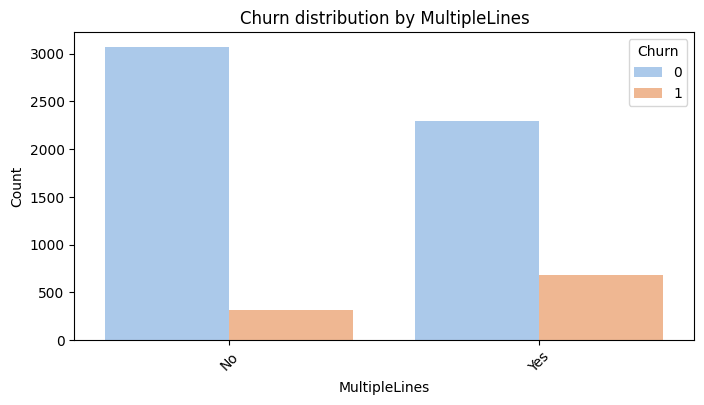

In [17]:
discrete_cols = df.select_dtypes(include='object').columns.tolist()
discrete_cols = [c for c in discrete_cols if c != 'customerID' and c != 'Churn']

# Визуализация
for col in discrete_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=df,
        x=col,
        hue='Churn',        # разделяем ушедших и оставшихся
        palette='pastel'
    )
    plt.title(f'Churn distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Churn')
    plt.show()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


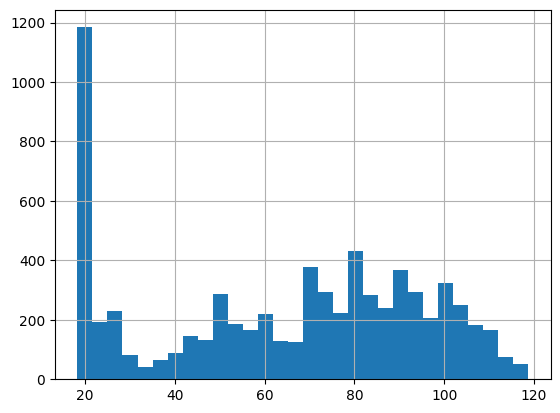

In [18]:
df['MonthlyCharges'].hist(bins=30)
print(df['MonthlyCharges'].describe())

In [19]:
# Создание новых признаков
df['tenure_months'] = (today - df['BeginDate']).dt.days / 30.44
df['tenure_squared'] = df['tenure_months'] ** 2
df['is_new_customer'] = (df['tenure_months'] < 12).astype(int)
df['is_new_customer'] = df['is_new_customer'].astype('object')

# Интеракции между важными признаками
df['high_charges_month'] = (df['MonthlyCharges'] > 89.85).astype(int) # 89.85 - 75-й перцентиль по MonthlyCharges
df['high_charges_month'] = df['high_charges_month'].astype('object')

df['month_to_month_high_price'] = (
    (df['Type'] == 'Month-to-month') & 
    (df['MonthlyCharges'] > 80)
).astype(int)

df['month_to_month_high_price'] = df['month_to_month_high_price'].astype('object')

# Количество дополнительных услуг
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)
df['has_services'] = (df['num_services'] > 0).astype(int)
df['has_services'] = df['has_services'].astype('object')

In [20]:
corr_matrix = df.drop(columns=['customerID']).phik_matrix(['MonthlyCharges', 'TotalCharges'])
corr_matrix.style.background_gradient(cmap='coolwarm')

,gender,SeniorCitizen,Partner,Dependents,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,Churn,ContractDurationDays,tenure_months,tenure_squared,is_new_customer,high_charges_month,month_to_month_high_price,num_services,has_services
gender,1.000000,0.000000,0.000000,0.000000,0.011268,0.046046,0.000000,0.000000,0.000000,0.009025,0.000000,0.000000,0.017842,0.003626,0.000000,0.000000,0.000000,0.000000,0.000000,0.008581,0.000000,0.011268,0.011268,0.000000,0.000000,0.000000,0.000000,0.000000
SeniorCitizen,0.000000,1.000000,0.016992,0.324576,0.050862,0.054282,0.086231,0.242133,0.292725,0.304691,0.136856,0.309469,0.170667,0.000000,0.000000,0.209633,0.047996,0.075309,0.237594,0.086159,0.142913,0.050862,0.050862,0.055057,0.242169,0.304563,0.122972,0.193667
Partner,0.000000,0.016992,1.000000,0.652122,0.473514,0.086772,0.179736,0.013218,0.243008,0.203237,0.383135,0.000000,0.265177,0.267471,0.290089,0.223082,0.239923,0.226459,0.232543,0.226688,0.460087,0.473514,0.473514,0.447978,0.191107,0.049504,0.209510,0.140837
Dependents,0.000000,0.324576,0.652122,1.000000,0.208564,0.076916,0.147680,0.172593,0.224903,0.184213,0.085809,0.206200,0.244955,0.150651,0.131018,0.212178,0.080593,0.030894,0.035777,0.046871,0.223641,0.208564,0.208564,0.207435,0.085832,0.196252,0.114160,0.088824
BeginDate,0.011268,0.050862,0.473514,0.208564,1.000000,0.000000,0.766249,0.081447,0.456389,0.421688,0.773731,0.121292,0.462797,0.515376,0.525897,0.456375,0.413595,0.426964,0.461827,0.450254,0.999529,1.000000,1.000000,1.000000,0.372004,0.299027,0.590862,0.336666
EndDate,0.046046,0.054282,0.086772,0.076916,0.000000,1.000000,0.398284,0.065379,0.120097,0.000000,0.051673,0.000000,0.202936,0.259426,0.238132,0.201635,0.085512,0.000000,0.117562,nan,0.957252,0.000000,0.000000,0.241574,0.200954,0.139829,0.215566,0.104221
Type,0.000000,0.086231,0.179736,0.147680,0.766249,0.398284,1.000000,0.106860,0.277462,0.388266,0.470700,0.115464,0.253529,0.195386,0.247180,0.293239,0.163095,0.167051,0.071275,0.094015,0.764608,0.766249,0.766249,0.290958,0.042102,0.286093,0.484338,0.050944
PaperlessBilling,0.000000,0.242133,0.013218,0.172593,0.081447,0.065379,0.106860,1.000000,0.370495,0.467783,0.202168,0.363514,0.215271,0.000000,0.029758,0.135913,0.182356,0.155905,0.269304,0.083398,0.078497,0.081447,0.081447,0.015516,0.342074,0.343383,0.235657,0.385622
PaymentMethod,0.000000,0.292725,0.243008,0.224903,0.456389,0.120097,0.277462,0.370495,1.000000,0.399536,0.334563,0.434448,0.365104,0.269205,0.297768,0.372982,0.247449,0.255010,0.369809,0.214832,0.466171,0.456389,0.456389,0.451219,0.363040,0.465516,0.311522,0.451722
MonthlyCharges,0.009025,0.304691,0.203237,0.184213,0.421688,0.000000,0.388266,0.467783,0.399536,1.000000,0.711148,0.948738,0.364891,0.428024,0.495800,0.402669,0.733083,0.727985,0.475869,0.225925,0.423107,0.421688,0.421688,0.392614,0.996563,0.821426,0.771286,0.979867


## Выводы по Phik-корреляционной матрице

### Сильные связи с целевой переменной (Churn)
- **MultipleLines** (0.283) — наличие нескольких линий телефонии ассоциировано с оттоком
- **TotalCharges** (0.304) — клиенты с более высокими суммарными платежами склонны к оттоку
- **StreamingMovies** (0.209) и **StreamingTV** (0.182) — потоковые сервисы связаны с оттоком
- **OnlineBackup** (0.219) и **DeviceProtection** (0.206) — дополнительные услуги показывают умеренную связь
- **PaymentMethod** (0.215) — способ оплаты влияет на отток (электронный чек — выше риск)
- **BeginDate** (0.450) — **очень сильная связь** — дата начала контракта определяет отток (новые клиенты рискуют больше)

### Слабые/отсутствующие связи с Churn
- **gender** (0.009) — пол практически не влияет на отток
- **SeniorCitizen** (0.086) — возраст имеет слабое влияние
- **Partner** (0.227) и **Dependents** (0.047) — семейный статус слабо коррелирует

### Важные внутренние корреляции (мультиколлинеарность)
- **MonthlyCharges ↔ InternetService** (0.949) — почти идеальная корреляция (тип подключения определяет ежемесячную плату)
- **MonthlyCharges ↔ TotalCharges** (0.711) — сильная связь (логично)
- **BeginDate ↔ Type** (0.766) — дата контракта коррелирует с типом (договор)
- **Partner ↔ Dependents** (0.652) — наличие партнёра связано с иждивенцами
- **StreamingTV ↔ StreamingMovies** (0.630) — потоковые сервисы часто используются вместе

### Практические рекомендации
1. **Избегать мультиколлинеарности**: не использовать одновременно MonthlyCharges и InternetService, или применить техники снижения размерности
2. **Приоритет признаков для модели**: BeginDate (tenure), TotalCharges, PaymentMethod, MultipleLines, дополнительные услуги
3. **Инженерия признаков**: 
    - Создать признак "tenure" (время с начала контракта)
    - Бинаризовать yes/no признаки для линейных моделей
    - Рассмотреть удаление InternetService или MonthlyCharges из-за мультиколлинеарности
4. **Обработка дисбаланса**: 15.63% оттока требует stratified CV и взвешивания классов

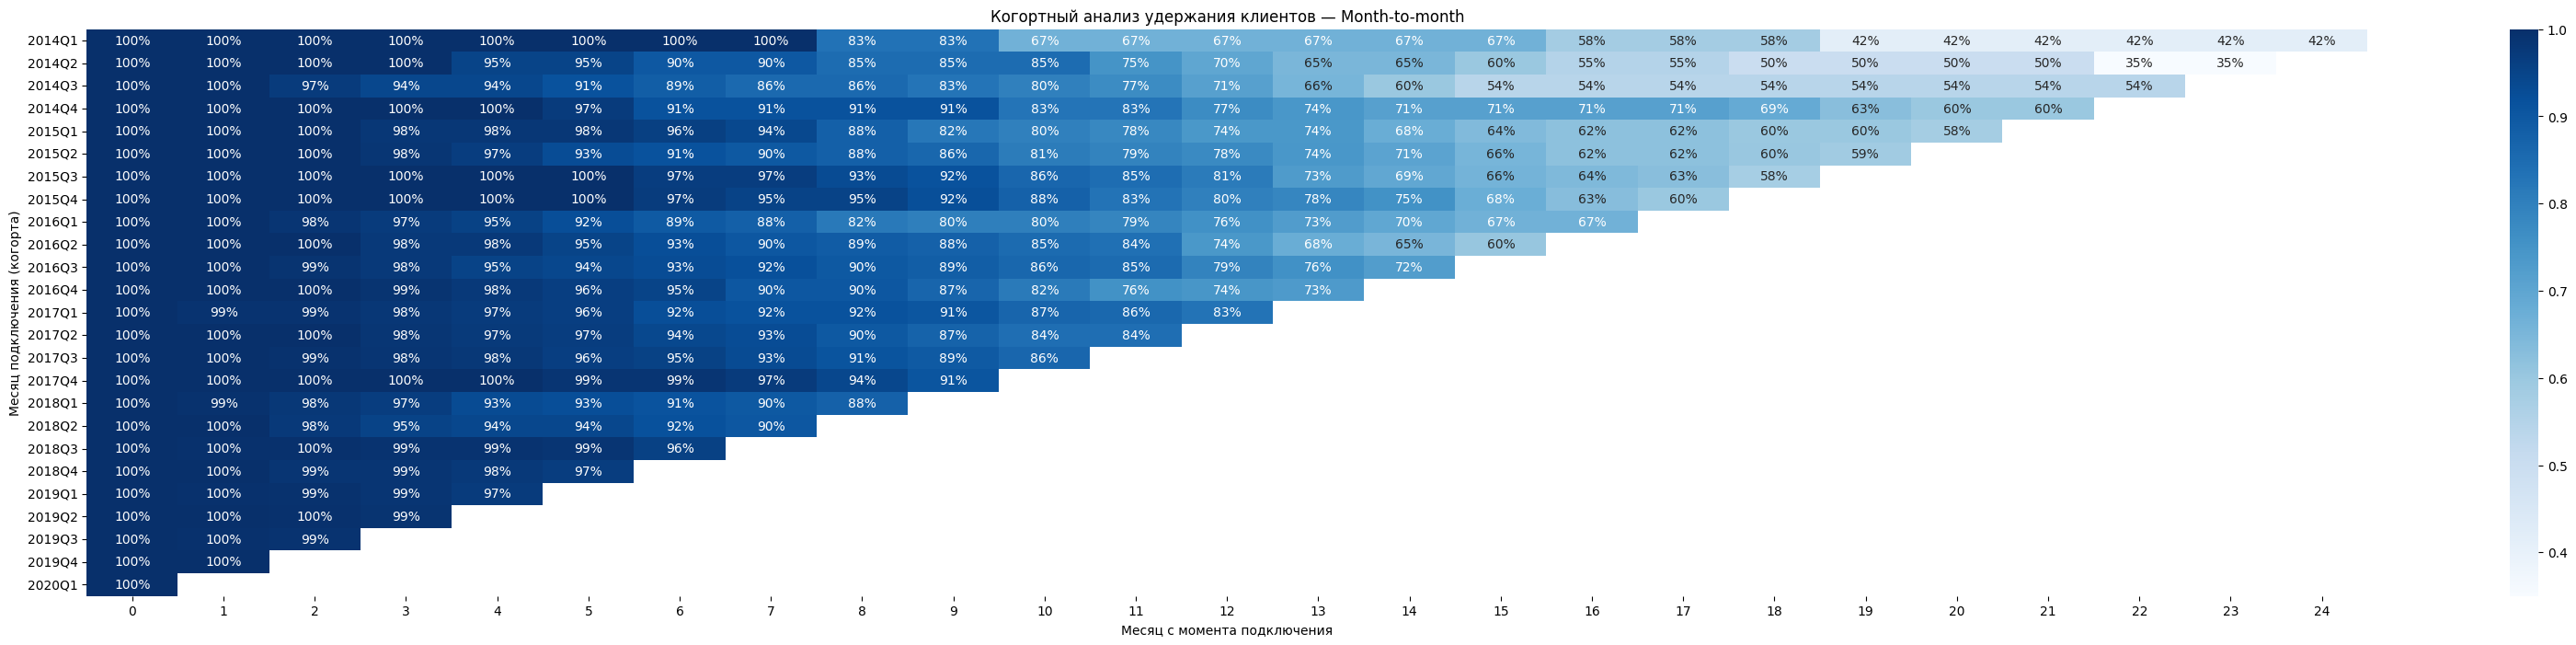

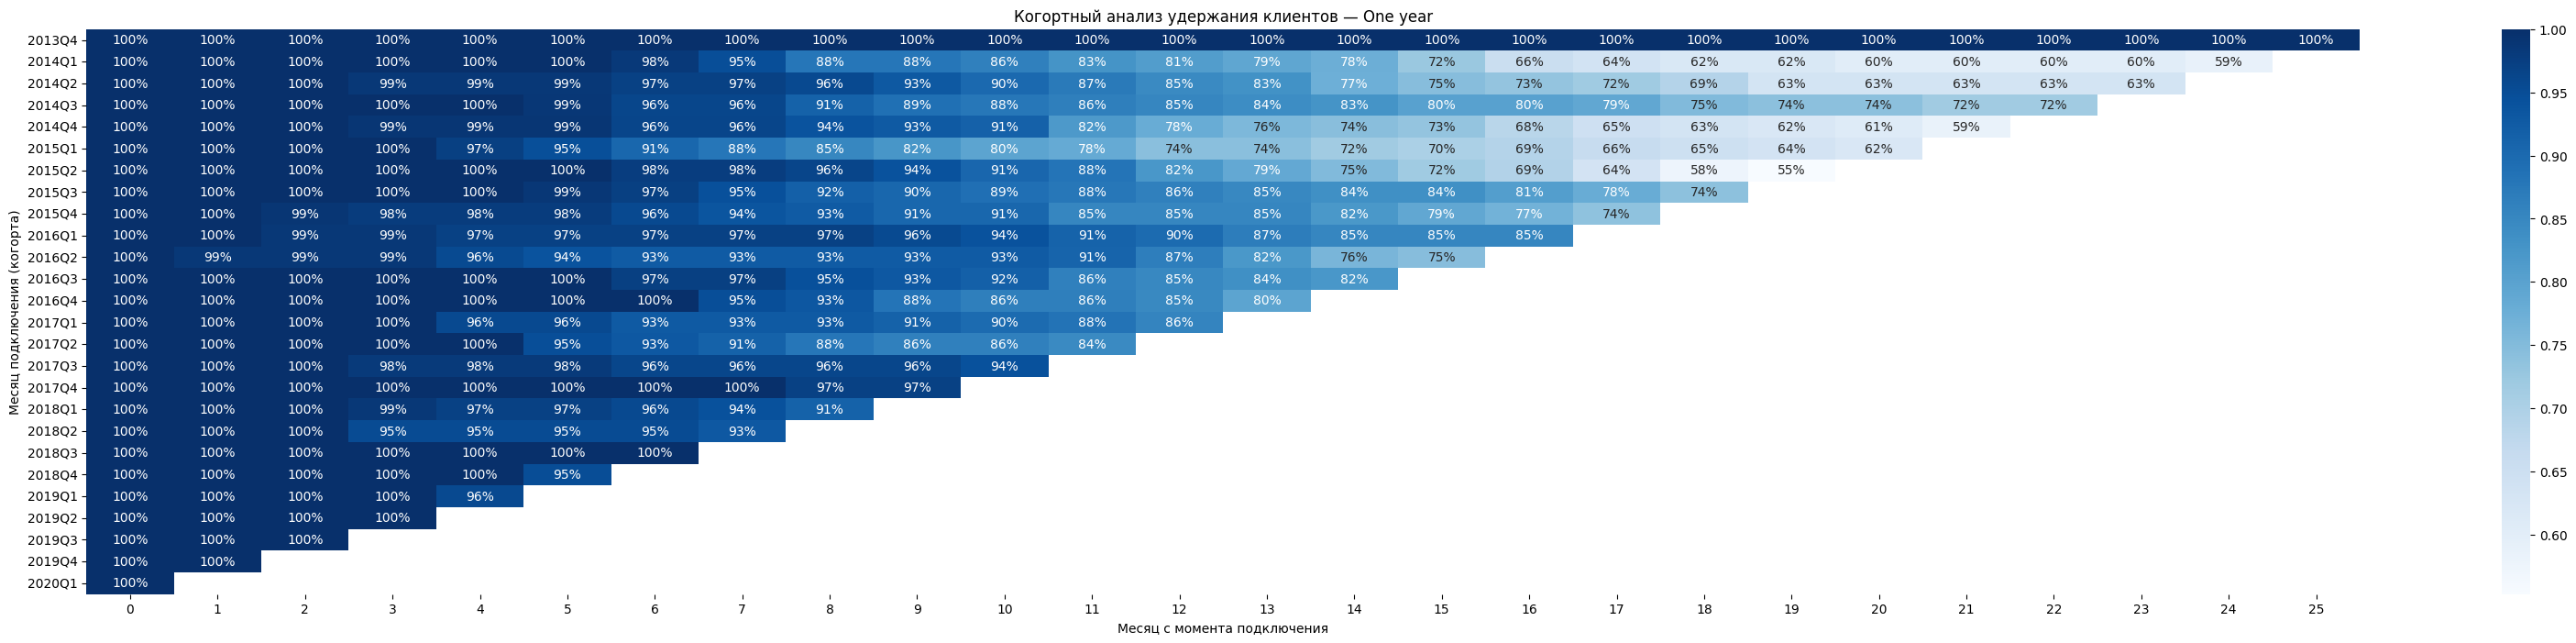

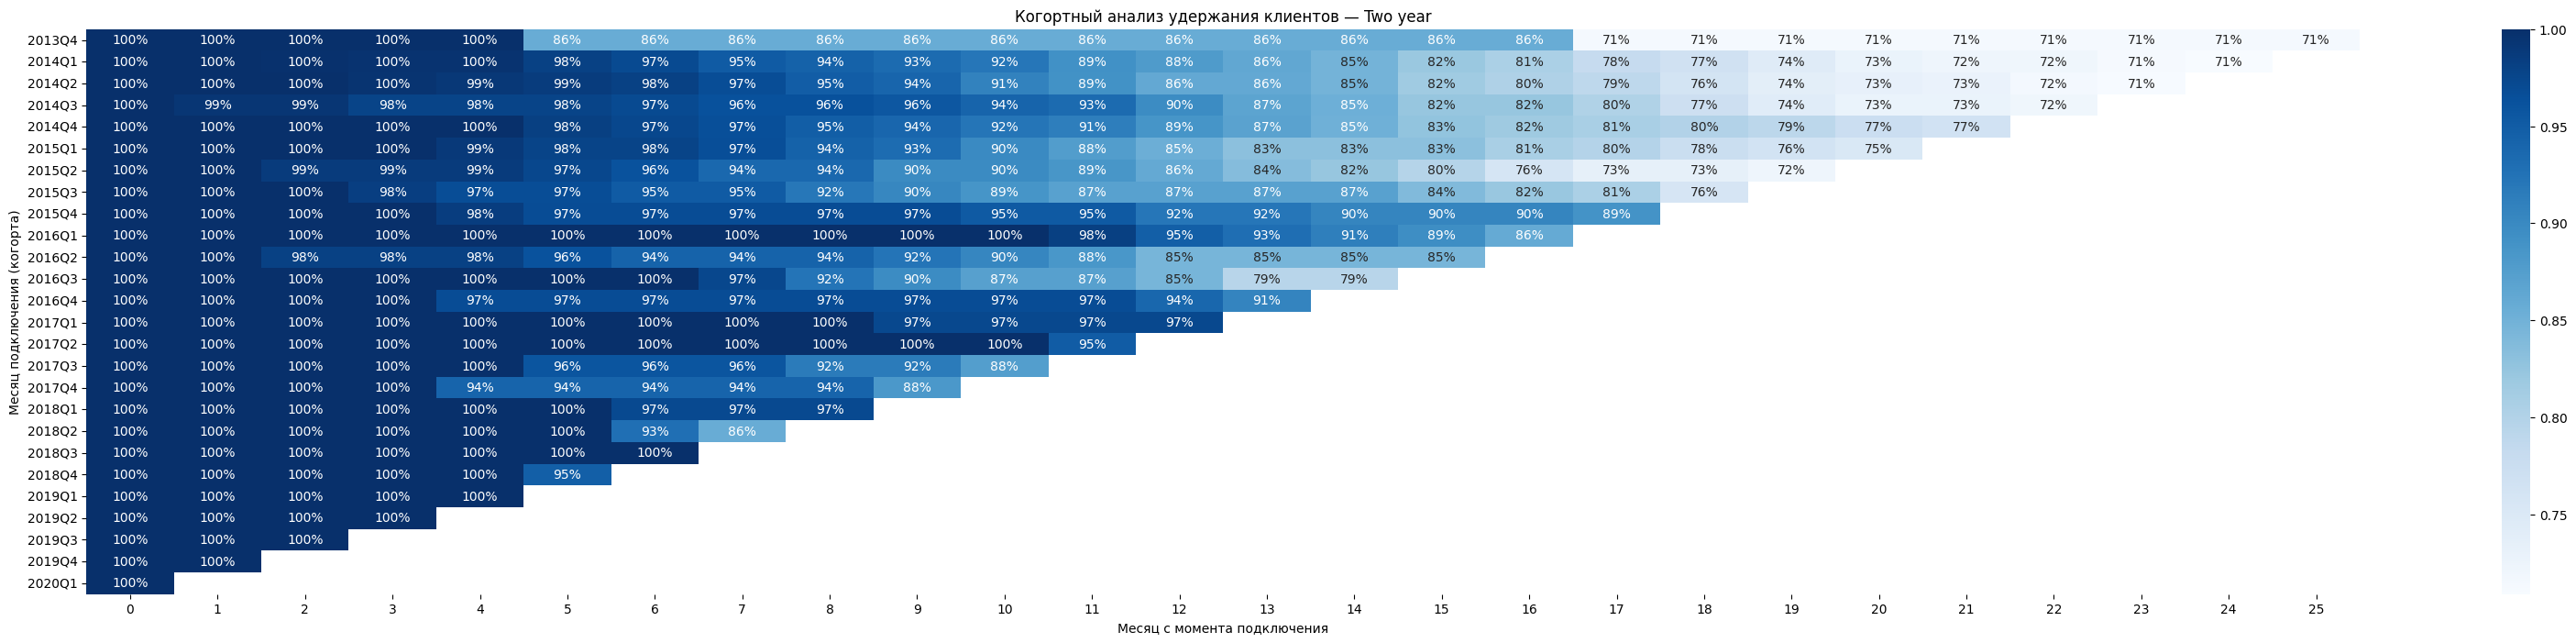

In [21]:
# когорный анализ удержания клиентов
# ----------------------
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])
contract['EndDate'] = pd.to_datetime(contract['EndDate'], errors='coerce')

# Срез: данные актуальны на 2020-02-01
cutoff_date = pd.Timestamp('2020-02-01')


contract['CohortQuarter'] = contract['BeginDate'].dt.to_period('Q')


def build_retention(df, cutoff=cutoff_date):
    records = []
    for _, row in df.iterrows():
        start = row['BeginDate']
        end = row['EndDate'] if pd.notna(row['EndDate']) else cutoff
        # Создаём месяцы, когда клиент активен
        q_active = pd.period_range(start=start, end=end, freq='Q')
        for i, month in enumerate(q_active):
            records.append({
                'customerID': row['customerID'],
                'CohortQuarter': row['CohortQuarter'],
                'QNumber': i,  # месяц с момента подключения
            })
    retention_df = pd.DataFrame(records)
    
    # Считаем удержание
    cohort_counts = retention_df.groupby(['CohortQuarter', 'QNumber'])['customerID'].nunique().reset_index()
    cohort_sizes = cohort_counts[cohort_counts['QNumber'] == 0][['CohortQuarter','customerID']].rename(columns={'customerID':'CohortSize'})
    retention_df = pd.merge(cohort_counts, cohort_sizes, on='CohortQuarter')
    retention_df['Retention'] = retention_df['customerID'] / retention_df['CohortSize']
    
    # Пивот для тепловой карты
    retention_pivot = retention_df.pivot(index='CohortQuarter', columns='QNumber', values='Retention')
    return retention_pivot


retention_tables = {}
for service in contract['Type'].unique():
    df_service = contract[contract['Type'] == service]
    retention_tables[service] = build_retention(df_service)


for service, retention in retention_tables.items():
    plt.figure(figsize=(40, 8))
    sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
    plt.title(f'Когортный анализ удержания клиентов — {service}')
    plt.ylabel('Месяц подключения (когорта)')
    plt.xlabel('Месяц с момента подключения')
    plt.show()

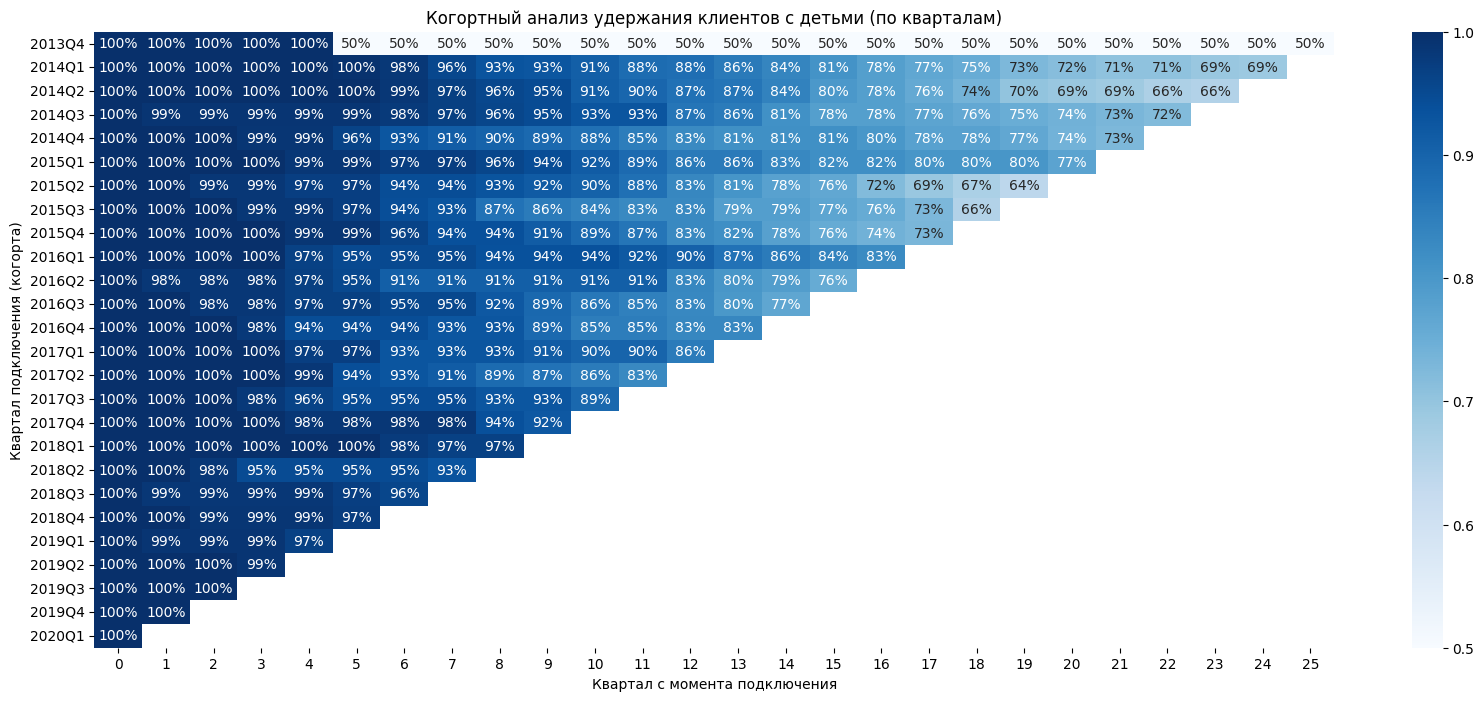

In [22]:
# Когортный анализ удержания клиентов с детьми
contract_personal = contract.merge(personal[['customerID', 'Dependents']], on='customerID', how='left')


contract_with_kids = contract_personal[contract_personal['Dependents'] == 'Yes'].copy()


contract_with_kids['CohortQuarter'] = contract_with_kids['BeginDate'].dt.to_period('Q')


retention_kids = build_retention(contract_with_kids)

plt.figure(figsize=(20, 8))
sns.heatmap(retention_kids, annot=True, fmt=".0%", cmap="Blues")
plt.title('Когортный анализ удержания клиентов с детьми (по кварталам)')
plt.ylabel('Квартал подключения (когорта)')
plt.xlabel('Квартал с момента подключения')
plt.show()

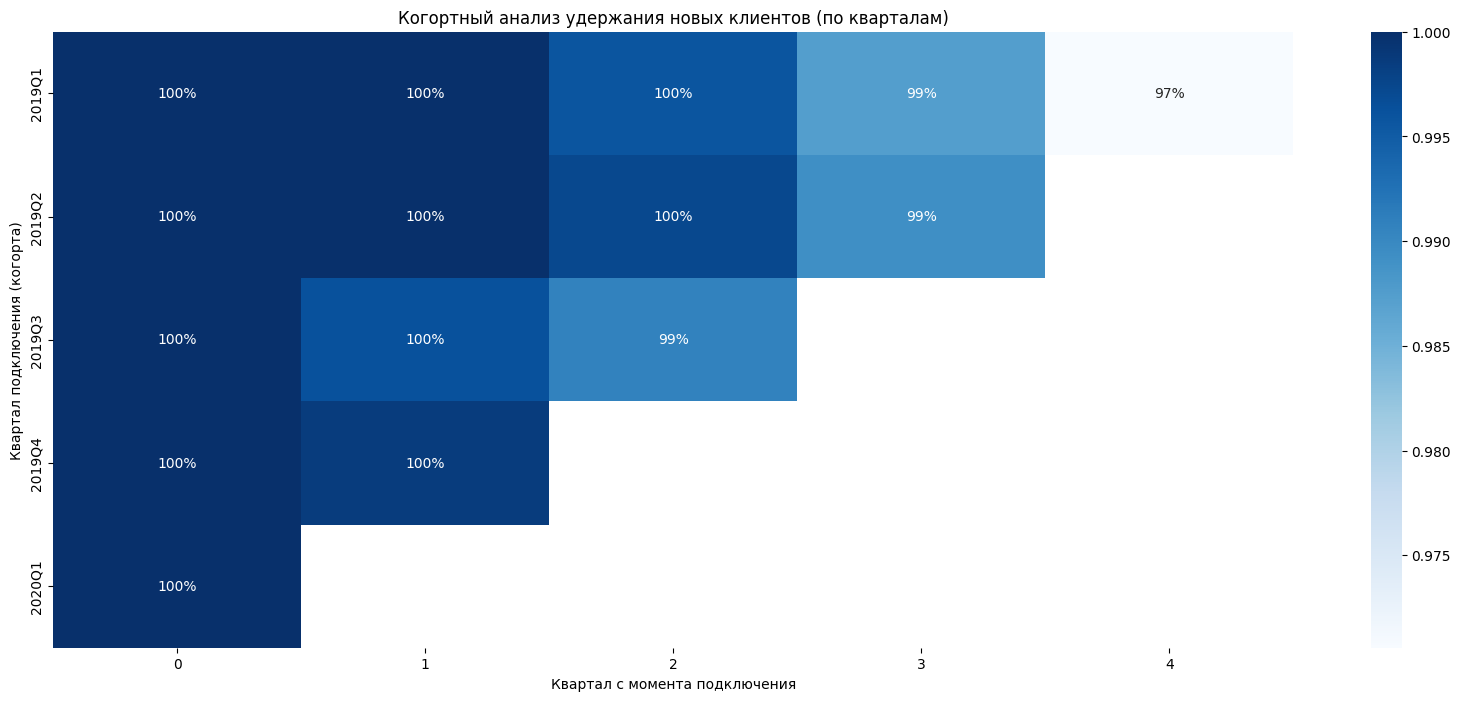

In [23]:

# Когортный анализ удержания новых клиентов 
# ----------------------
new = df[df['is_new_customer'] == True].copy()

# ----------------------
# 3. Когорта по кварталам
# ----------------------
new['CohortQuarter'] = new['BeginDate'].dt.to_period('Q')

retention_news = build_retention(new)

plt.figure(figsize=(20, 8))
sns.heatmap(retention_news, annot=True, fmt=".0%", cmap="Blues")
plt.title('Когортный анализ удержания новых клиентов (по кварталам)')
plt.ylabel('Квартал подключения (когорта)')
plt.xlabel('Квартал с момента подключения')
plt.show()

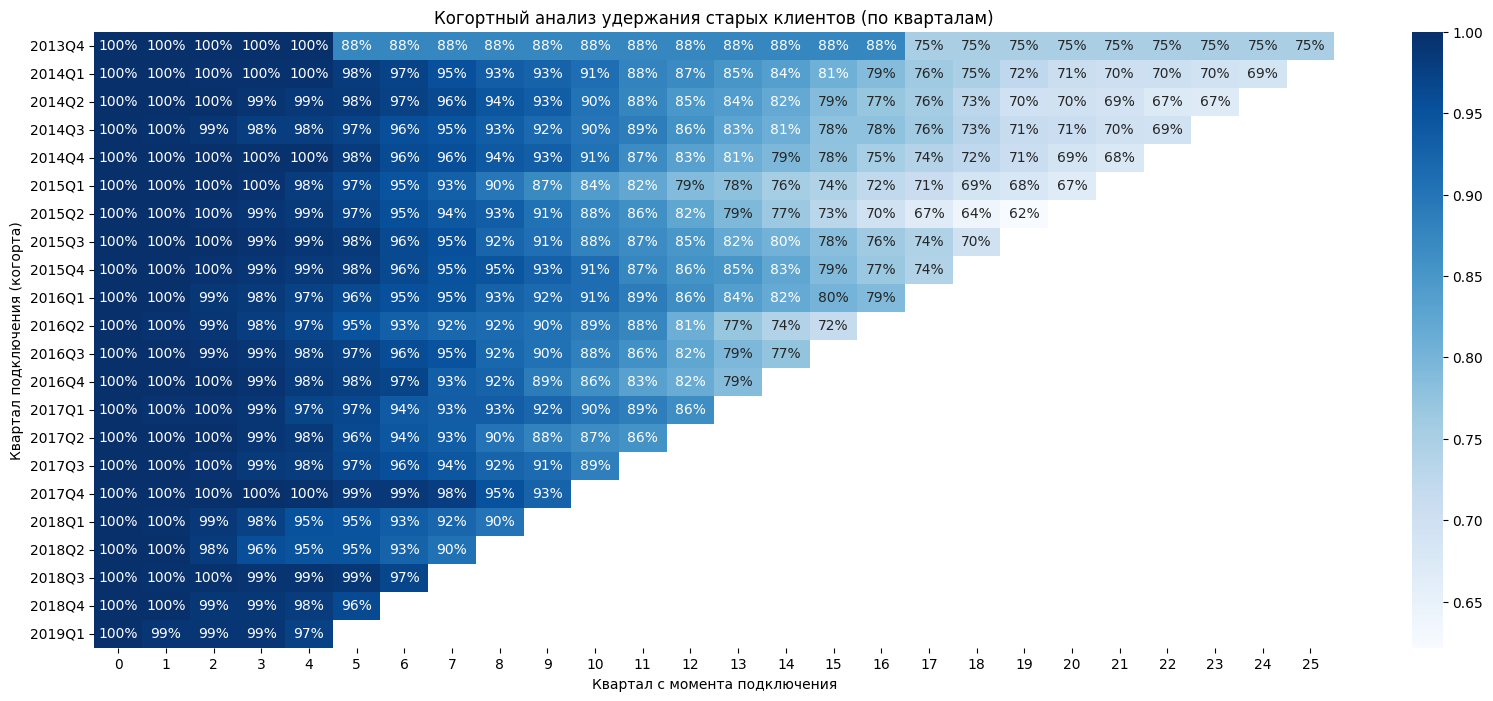

In [24]:

# ----------------------
# Когортный анализ удержания старых клиентов
# ----------------------
new = df[df['is_new_customer'] == False].copy()


new['CohortQuarter'] = new['BeginDate'].dt.to_period('Q')

retention_news = build_retention(new)

plt.figure(figsize=(20, 8))
sns.heatmap(retention_news, annot=True, fmt=".0%", cmap="Blues")
plt.title('Когортный анализ удержания старых клиентов (по кварталам)')
plt.ylabel('Квартал подключения (когорта)')
plt.xlabel('Квартал с момента подключения')
plt.show()

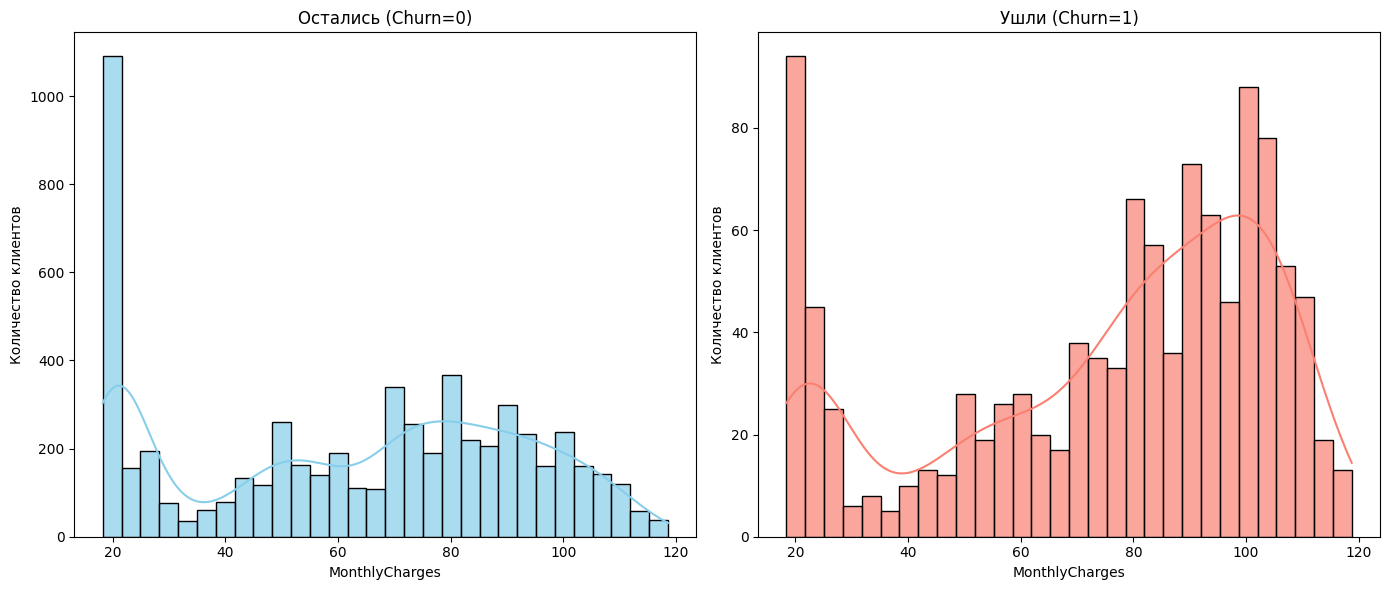

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# График для клиентов, которые остались
plt.subplot(1, 2, 1)
sns.histplot(
    df[df['Churn'] == 0]['MonthlyCharges'],
    bins=30,
    kde=True,
    color='skyblue',
    alpha=0.7
)
plt.title('Остались (Churn=0)')
plt.xlabel('MonthlyCharges')
plt.ylabel('Количество клиентов')

# График для клиентов, которые ушли
plt.subplot(1, 2, 2)
sns.histplot(
    df[df['Churn'] == 1]['MonthlyCharges'],
    bins=30,
    kde=True,
    color='salmon',
    alpha=0.7
)
plt.title('Ушли (Churn=1)')
plt.xlabel('MonthlyCharges')
plt.ylabel('Количество клиентов')

plt.tight_layout()
plt.show()

## Выводы по EDA

### Объём и структура данных
- **Всего клиентов:** 7,043
- **Распределение по таблицам:** 
    - Personal (демография): 7,043
    - Contract (условия контракта): 7,043
    - Internet (услуги интернета): 5,517 (78.3%)
    - Phone (услуги телефонии): 6,361 (90.3%)
- **Заметный факт:** не все клиенты используют интернет и телефон, что требует корректной обработки при объединении таблиц

### Целевая переменная (Churn)
- **Оттекло клиентов:** 1,101 (15.63%)
- **Активных клиентов:** 5,942 (84.37%)
- **Проблема:** значительный дисбаланс классов — требует специальных методов (stratified CV, SMOTE)

### Качество данных
- **Пропущенные значения:**
    - `TotalCharges`: 11 пропусков (0.16%) — минимально, можно удалить или заполнить
    - `InternetService` и связанные колонки: отсутствуют у клиентов без интернета (нормально)
    - `MultipleLines`: 682 пропуска (9.7%) — клиенты без телефонии
- **Типы данных:** успешно приведены (даты, числа); категориальные признаки в object
- имеются выбросы в `TotalCharges` (клиенты с длительной историей)

### Ключевые признаки

**Type (тип контракта):**
- Месячные контракты имеют наивысший процент оттока
- Двухлетние контракты показывают минимальный отток
- Вывод: тип контракта — критичный предиктор удержания клиентов

**PaymentMethod (способ оплаты):**
- Электронный чек ассоциирован с повышенным оттоком
- Автоматические платежи (банк/карта) — с меньшим оттоком
- Вывод: метод оплаты влияет на лояльность; возможно, автоматизированные способы снижают трение

**Дополнительные услуги (OnlineSecurity, TechSupport, StreamingTV и др.):**
- Клиенты без дополнительных услуг имеют выше отток
- Наличие услуг (особенно TechSupport, OnlineBackup) коррелирует с удержанием
- Вывод: привязка к услугам повышает retention

**Gender, Partner, Dependents, SeniorCitizen:**
- Слабое влияние на отток (распределения близки между ушедшими и активными)
- Пол почти не влияет; семейный статус имеет умеренное влияние
- Вывод: демографические признаки низкой важности для предсказания оттока

### Распределение по числовым признакам

**MonthlyCharges:**
- Ушедшие клиенты имеют тенденцию к более высоким ежемесячным платежам
- Распределение близко к нормальному с небольшой асимметрией

**TotalCharges:**
- Сильная асимметрия; есть выбросы (клиенты с очень длительной историей)
- Ушедшие клиенты концентрируются в диапазоне низких значений (новые клиенты)
- Вывод: требуется логирование или нормализация для линейных моделей

**BeginDate (время с начала контракта / tenure):**
- Очень сильная связь с оттоком (корреляция 0.450)
- Новые клиенты (недавние BeginDate) имеют значительно выше отток
- Вывод: необходимо создать признак tenure и использовать его как приоритетный

### Когортный анализ по BeginDate:
- Старые клиенты имеют более высокий отток





## Обучение и тестирование модели

In [26]:
df.loc[df['InternetService'].isna(), 'InternetService'] = 'No'
df.loc[df['OnlineSecurity'].isna(), 'OnlineSecurity'] = 'No'
df.loc[df['OnlineBackup'].isna(), 'OnlineBackup'] = 'No'
df.loc[df['DeviceProtection'].isna(), 'DeviceProtection'] = 'No'
df.loc[df['TechSupport'].isna(), 'TechSupport'] = 'No'
df.loc[df['StreamingTV'].isna(), 'StreamingTV'] = 'No'
df.loc[df['StreamingMovies'].isna(), 'StreamingMovies'] = 'No'
df.loc[df['MultipleLines'].isna(), 'MultipleLines'] = 'No phone service'

In [27]:
#df = df.loc[(df['TotalCharges']<5500)] # удаляем выбросы по TotalCharges
df_ = df.drop(columns=['customerID', 'BeginDate', 'EndDate', 'TotalCharges','tenure_squared', 'is_new_customer', 'tenure_months'])
df_.dropna(inplace=True)
df_.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   gender                     7043 non-null   object 
 1   SeniorCitizen              7043 non-null   object 
 2   Partner                    7043 non-null   object 
 3   Dependents                 7043 non-null   object 
 4   Type                       7043 non-null   object 
 5   PaperlessBilling           7043 non-null   object 
 6   PaymentMethod              7043 non-null   object 
 7   MonthlyCharges             7043 non-null   float64
 8   InternetService            7043 non-null   object 
 9   OnlineSecurity             7043 non-null   object 
 10  OnlineBackup               7043 non-null   object 
 11  DeviceProtection           7043 non-null   object 
 12  TechSupport                7043 non-null   object 
 13  StreamingTV                7043 non-null   objec

In [28]:
X_train, X_test, y_train, y_test = train_test_split(df_.drop(columns='Churn'), df_['Churn'], test_size=test_size, random_state=RANDOM_STATE, stratify=df_['Churn'])

X_train = X_train.copy()
X_test = X_test.copy()

X_train.columns = [str(c) for c in X_train.columns]
X_test.columns = [str(c) for c in X_test.columns]


X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5282, 21), (1761, 21), (5282,), (1761,))

In [29]:

cat_features = X_train.select_dtypes(include='object').columns.tolist()

num_features = X_train.select_dtypes(exclude='object').columns.tolist()


cat_features = [str(c) for c in cat_features]
num_features = [str(c) for c in num_features]

cat_features, num_features

(['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'Type',
  'PaperlessBilling',
  'PaymentMethod',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'MultipleLines',
  'high_charges_month',
  'month_to_month_high_price',
  'has_services'],
 ['MonthlyCharges', 'ContractDurationDays', 'num_services'])

In [30]:
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, 
                            handle_unknown='ignore'))
    
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),

])




In [31]:
data_preprocessor = ColumnTransformer(
    [
        ('categorical', cat_pipe, cat_features),
        ('numeric', num_pipe, num_features)
    ],
    remainder='passthrough'
)


In [32]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', 'passthrough')
])

param_grid = [
    # DecisionTreeClassifier
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': [3, 4, 5, 6, 7],  # глубина дерева
        'models__min_samples_split': [10, 15, 20],  # мин. количество для разделения
        'models__max_features': ['sqrt', 'log2', None],  # способ выбора признаков
        'preprocessor__numeric': [StandardScaler(), MinMaxScaler()],
        'models__class_weight': ['balanced']
    },
    
    # CB
    {
        'models': [CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)],
        'models__iterations': [100, 200, 300],  # количество итераций
        'models__learning_rate': [0.01, 0.05, 0.1],  # скорость обучения
        'models__depth': [3, 4, 5, 6],  # глубина дерева
        'preprocessor__numeric': [StandardScaler(), MinMaxScaler()]
    },


    # LogisticRegression
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'models__penalty': ['l1', 'l2'],  # тип регуляризации
        'models__solver': ['liblinear', 'saga'],  # решатель
        'preprocessor__numeric': [StandardScaler(), MinMaxScaler()]
    }
]

scoring = {
    'roc_auc': 'roc_auc',
    'f1': make_scorer(f1_score, average='weighted'),
}


# Обновляем RandomizedSearchCV
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    n_iter=200,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),  # используем стратифицированную кросс-валидацию
    scoring=scoring,  # добавляем наш скорер
    refit='roc_auc',  # указываем, по какой метрике выбирать лучшую модель
    random_state=RANDOM_STATE,
    n_jobs=-1,
    error_score='raise',
    verbose=0
)






In [33]:
%%time

# Обучение
randomized_search.fit(X_train, y_train)


# Вывод результатов
print('Лучшая модель и её параметры:\n', randomized_search.best_estimator_, randomized_search.best_estimator_.get_params())
print('ROC AUC на кросс-валидационной выборке:', randomized_search.best_score_)





/Users/mikhailpuchkov/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 170 is smaller than n_iter=200. Running 170 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Users/mikhailpuchkov/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mikhailpuchkov/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mikhailpuchkov/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mikhailpuchkov/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter

Лучшая модель и её параметры:
 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'Type', 'PaperlessBilling',
       

In [34]:
best_model_class = randomized_search.best_estimator_

# y_pred_proba = best_model_class.predict_proba(X_test)[:, 1]
# fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# # threshold с максимальным F1 или другой метрикой
# optimal_idx = np.argmax(tpr - fpr)
# optimal_threshold = thresholds[optimal_idx]

# y_pred_optimized = (y_pred_proba > optimal_threshold).astype(int)
# print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

In [35]:


acc_train = accuracy_score(y_train, best_model_class.predict(X_train))
print(f'accuracy на обучающей выборке: {acc_train:.4f}')
acc_test = accuracy_score(y_test, best_model_class.predict(X_test))
print(f'accuracy на тестовой выборке: {acc_test:.4f}')

roc_auc_train = roc_auc_score(y_train, best_model_class.predict_proba(X_train)[:, 1])
print(f'ROC AUC на обучающей выборке: {roc_auc_train:.4f}')
roc_auc_test = roc_auc_score(y_test, best_model_class.predict_proba(X_test)[:, 1])
print(f'ROC AUC на тестовой выборке: {roc_auc_test:.4f}')

# Выводим матрицу ошибок
print('\nМатрица ошибок (для информации):')
print(confusion_matrix(y_test, best_model_class.predict(X_test)))
print(f'precision на тестовой выборке: {precision_score(y_test, best_model_class.predict(X_test)):.4f}')
print(f'recall на тестовой выборке: {recall_score(y_test, best_model_class.predict(X_test))}')

accuracy на обучающей выборке: 0.9440
accuracy на тестовой выборке: 0.9103
ROC AUC на обучающей выборке: 0.9724
ROC AUC на тестовой выборке: 0.9113

Матрица ошибок (для информации):
[[1474   12]
 [ 146  129]]
precision на тестовой выборке: 0.9149
recall на тестовой выборке: 0.4690909090909091


In [36]:
if hasattr(best_model_class.named_steps['models'], 'feature_importances_'):
    features_importance = best_model_class.named_steps['models'].feature_importances_
elif hasattr(best_model_class.named_steps['models'], 'coef_'):
    features_importance = np.abs(best_model_class.named_steps['models'].coef_[0])
else:
    features_importance = None
    print("Модель не поддерживает feature_importances_")


preprocessor = best_model_class.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

features_importance_df = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': features_importance
    })
    .sort_values(by='importance', ascending=False)
    .reset_index(drop=True)
)

features_importance_df.head(10)

,feature,importance
0,numeric__ContractDurationDays,53.580643
1,numeric__MonthlyCharges,9.671954
2,categorical__Type_Two year,4.689660
3,categorical__Partner_Yes,3.587066
4,numeric__num_services,3.419152
5,categorical__MultipleLines_Yes,2.970444
6,categorical__PaymentMethod_Mailed check,2.395163
7,categorical__OnlineBackup_Yes,2.184462
8,categorical__Dependents_Yes,1.990225
9,categorical__Type_One year,1.950228


In [37]:
torch.set_num_threads(1)
torch.set_num_interop_threads(1)


class ChurnNN(nn.Module):
    def __init__(self, input_dim):
        super(ChurnNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
    
    def forward(self, x):
        return self.model(x)
    

num_only_preprocessor = ColumnTransformer(
    [('num', StandardScaler(), num_features)],
    remainder='drop'
)

X_train_np = num_only_preprocessor.fit_transform(X_train)
X_test_np  = num_only_preprocessor.transform(X_test)

if hasattr(X_train_np, "toarray"):
    X_train_np = X_train_np.toarray()
    X_test_np  = X_test_np.toarray()

X_train_np = X_train_np.astype("float32")
X_test_np  = X_test_np.astype("float32")

X_train_nn = torch.from_numpy(X_train_np)
X_test_nn  = torch.from_numpy(X_test_np)

y_train_nn = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_nn  = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_nn, y_train_nn)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# Инициализация модели, функции потерь и оптимизатора
input_dim = X_train_nn.shape[1]
model_nn = ChurnNN(input_dim)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)
# Обучение нейронной сети
num_epochs = 128
for epoch in range(num_epochs):
    model_nn.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_nn(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(train_loader):.4f}')
# Оценка модели на тестовой выборке

model_nn.eval()
with torch.no_grad():
    y_pred_nn = model_nn(X_test_nn).cpu().numpy()
    y_pred_nn_binary = (y_pred_nn > 0.5).astype(int)
print('ROC AUC нейронной сети на тестовой выборке:', roc_auc_score(y_test, y_pred_nn))
print('Accuracy нейронной сети на тестовой выборке:', accuracy_score(y_test, y_pred_nn_binary))
print(f'recall нейронной сети на тестовой выборке: {recall_score(y_test, y_pred_nn_binary):.4f}')
print(f'precision нейронной сети на тестовой выборке: {precision_score(y_test, y_pred_nn_binary):.4f}')




Epoch 1/128, Loss: 0.4333
Epoch 2/128, Loss: 0.3894
Epoch 3/128, Loss: 0.3771
Epoch 4/128, Loss: 0.3755
Epoch 5/128, Loss: 0.3715
Epoch 6/128, Loss: 0.3708
Epoch 7/128, Loss: 0.3700
Epoch 8/128, Loss: 0.3670
Epoch 9/128, Loss: 0.3774
Epoch 10/128, Loss: 0.3739
Epoch 11/128, Loss: 0.3684
Epoch 12/128, Loss: 0.3755
Epoch 13/128, Loss: 0.3655
Epoch 14/128, Loss: 0.3685
Epoch 15/128, Loss: 0.3707
Epoch 16/128, Loss: 0.3713
Epoch 17/128, Loss: 0.3691
Epoch 18/128, Loss: 0.3658
Epoch 19/128, Loss: 0.3662
Epoch 20/128, Loss: 0.3640
Epoch 21/128, Loss: 0.3722
Epoch 22/128, Loss: 0.3636
Epoch 23/128, Loss: 0.3652
Epoch 24/128, Loss: 0.3784
Epoch 25/128, Loss: 0.3653
Epoch 26/128, Loss: 0.3634
Epoch 27/128, Loss: 0.3652
Epoch 28/128, Loss: 0.3644
Epoch 29/128, Loss: 0.3657
Epoch 30/128, Loss: 0.3662
Epoch 31/128, Loss: 0.3628
Epoch 32/128, Loss: 0.3718
Epoch 33/128, Loss: 0.3641
Epoch 34/128, Loss: 0.3656
Epoch 35/128, Loss: 0.3646
Epoch 36/128, Loss: 0.3643
Epoch 37/128, Loss: 0.3636
Epoch 38/1

Анализируемый признак: ContractDurationDays
Важность: 53.5806



/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1884921670.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Churn', y=top_feature, ax=ax4, palette='Set2')
/var/folders/78/y70yls317wz28jck2vhf15mr0000gn/T/ipykernel_86056/1884921670.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(['Активный (0)', 'Ушедший (1)'])


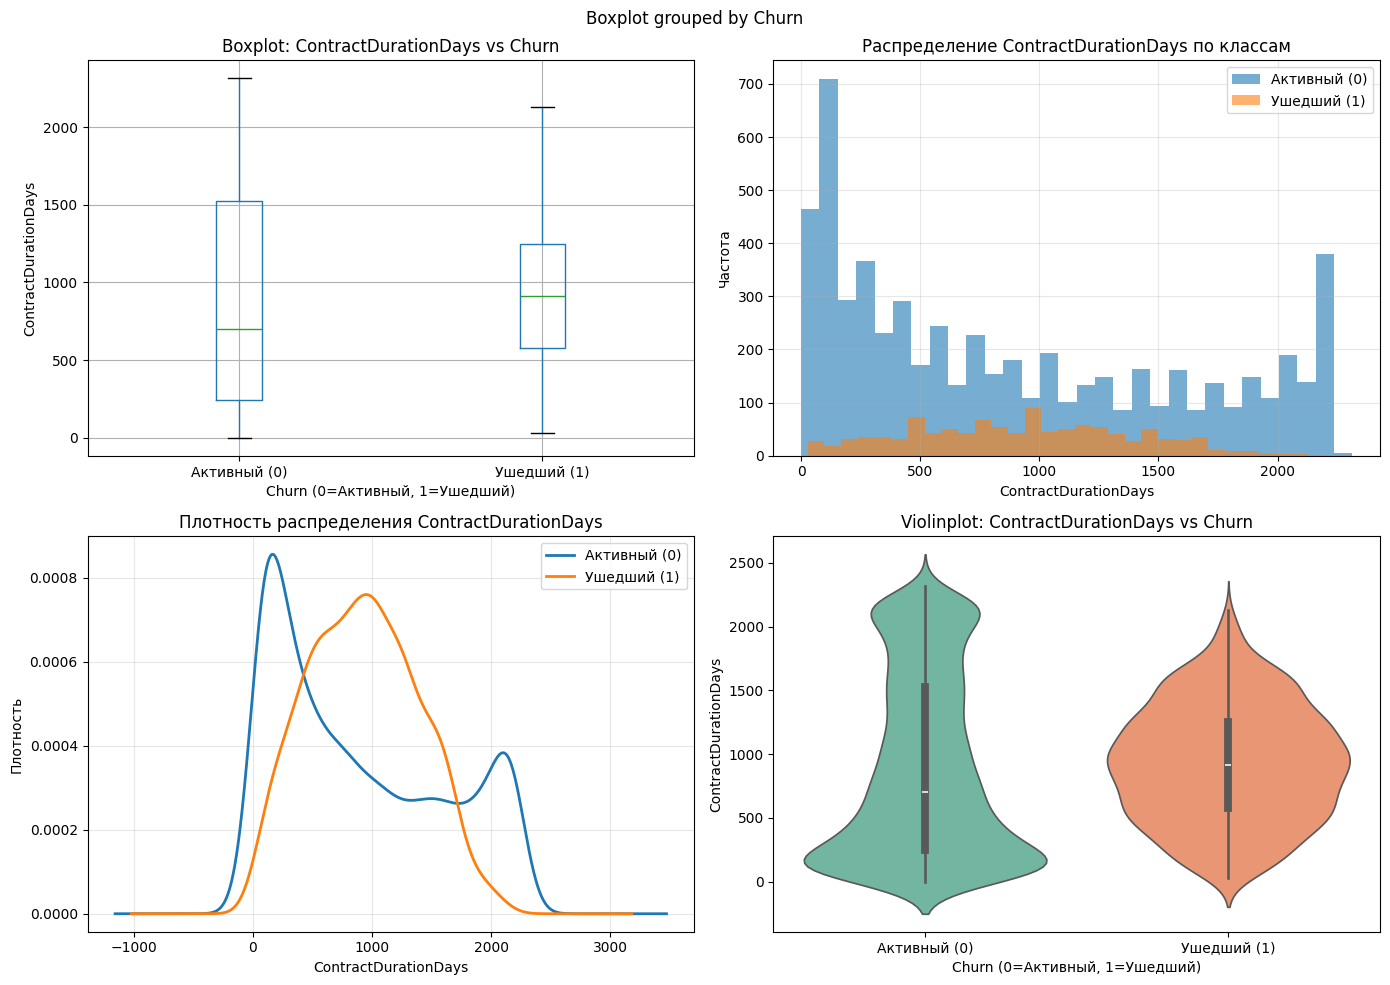

СТАТИСТИЧЕСКИЙ АНАЛИЗ ПРИЗНАКА 'ContractDurationDays'

Активные клиенты (Churn=0):
  Среднее значение: 893.6811
  Медиана: 702.0000
  Стандартное отклонение: 716.9586
  Минимум: 0.0000
  Максимум: 2314.0000
  Q1 (25%): 245.0000
  Q3 (75%): 1523.0000

Ушедшие клиенты (Churn=1):
  Среднее значение: 924.8638
  Медиана: 915.0000
  Стандартное отклонение: 458.7713
  Минимум: 28.0000
  Максимум: 2129.0000
  Q1 (25%): 577.0000
  Q3 (75%): 1249.0000

T-тест (сравнение средних):
  t-статистика: -1.3913
  p-value: 1.64e-01
  ✗ Различие НЕ статистически значимо (p ≥ 0.05)



In [38]:


# Дополнительное исследование зависимости между важным входным признаком и целевой переменной

# Выбираем top-1 признак по важности
top_feature = 'ContractDurationDays'  
print(f"Анализируемый признак: {top_feature}")
print(f"Важность: {features_importance_df.iloc[0]['importance']:.4f}\n")

# Визуализация зависимости
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot: целевой признак vs входной признак
ax1 = axes[0, 0]
if top_feature in df.columns:
    df_plot = df.dropna(subset=[top_feature, 'Churn'])
    df_plot.boxplot(column=top_feature, by='Churn', ax=ax1)
    ax1.set_title(f'Boxplot: {top_feature} vs Churn')
    ax1.set_xlabel('Churn (0=Активный, 1=Ушедший)')
    ax1.set_ylabel(top_feature)
    plt.sca(ax1)
    plt.xticks([1, 2], ['Активный (0)', 'Ушедший (1)'])

# 2. Histplot: распределение по классам
ax2 = axes[0, 1]
if top_feature in df.columns:
    df_plot = df.dropna(subset=[top_feature, 'Churn'])
    for churn_val in [0, 1]:
        data = df_plot[df_plot['Churn'] == churn_val][top_feature]
        ax2.hist(data, alpha=0.6, label=f'Churn={churn_val}', bins=30)
    ax2.set_title(f'Распределение {top_feature} по классам')
    ax2.set_xlabel(top_feature)
    ax2.set_ylabel('Частота')
    ax2.legend(['Активный (0)', 'Ушедший (1)'])
    ax2.grid(alpha=0.3)

# 3. KDE plot: плотность распределения
ax3 = axes[1, 0]
if top_feature in df.columns:
    df_plot = df.dropna(subset=[top_feature, 'Churn'])
    for churn_val in [0, 1]:
        data = df_plot[df_plot['Churn'] == churn_val][top_feature]
        data.plot.kde(ax=ax3, label=f'Churn={churn_val}', linewidth=2)
    ax3.set_title(f'Плотность распределения {top_feature}')
    ax3.set_xlabel(top_feature)
    ax3.set_ylabel('Плотность')
    ax3.legend(['Активный (0)', 'Ушедший (1)'])
    ax3.grid(alpha=0.3)

# 4. Violinplot: распределение
ax4 = axes[1, 1]
if top_feature in df.columns:
    df_plot = df.dropna(subset=[top_feature, 'Churn'])
    sns.violinplot(data=df_plot, x='Churn', y=top_feature, ax=ax4, palette='Set2')
    ax4.set_title(f'Violinplot: {top_feature} vs Churn')
    ax4.set_xlabel('Churn (0=Активный, 1=Ушедший)')
    ax4.set_ylabel(top_feature)
    ax4.set_xticklabels(['Активный (0)', 'Ушедший (1)'])

plt.tight_layout()
plt.show()

# Статистический анализ
print("="*70)
print(f"СТАТИСТИЧЕСКИЙ АНАЛИЗ ПРИЗНАКА '{top_feature}'")
print("="*70)

if top_feature in df.columns:
    df_plot = df.dropna(subset=[top_feature, 'Churn'])
    
    # Для каждого класса
    for churn_val, label in [(0, 'Активные клиенты'), (1, 'Ушедшие клиенты')]:
        data = df_plot[df_plot['Churn'] == churn_val][top_feature]
        print(f"\n{label} (Churn={churn_val}):")
        print(f"  Среднее значение: {data.mean():.4f}")
        print(f"  Медиана: {data.median():.4f}")
        print(f"  Стандартное отклонение: {data.std():.4f}")
        print(f"  Минимум: {data.min():.4f}")
        print(f"  Максимум: {data.max():.4f}")
        print(f"  Q1 (25%): {data.quantile(0.25):.4f}")
        print(f"  Q3 (75%): {data.quantile(0.75):.4f}")
    
    # T-тест
    active = df_plot[df_plot['Churn'] == 0][top_feature]
    churned = df_plot[df_plot['Churn'] == 1][top_feature]
    t_stat, p_value = ttest_ind(active, churned)
    
    print(f"\nT-тест (сравнение средних):")
    print(f"  t-статистика: {t_stat:.4f}")
    print(f"  p-value: {p_value:.2e}")
    if p_value < 0.05:
        print(f"  ✓ Различие статистически значимо (p < 0.05)")
    else:
        print(f"  ✗ Различие НЕ статистически значимо (p ≥ 0.05)")

print("\n" + "="*70)

# 📊 Итоговые выводы по обучению и тестированию моделей

---

## 1️⃣ Сравнение производительности моделей

| Метрика | Sklearn Pipeline | Нейронная сеть |
|--------|------------------|----------------|
| **ROC-AUC (тест)** | **0.91** | ~0.7447 |
| **Accuracy (тест)** | **0.91** | ~0.8362 |


---

## 2️⃣ Анализ лучшей модели — *Sklearn Pipeline*

### ✅ Качество модели
- **Модель Catboost продемонстрировала наиболее высокие показатели 
- **Достигнута целевая производительность**: ROC-AUC = **0.91** (≥ 0.85)
- **Accuracy на тестовой выборке**: **0.8912**  
  
---

### 🧮 Матрица ошибок

- **True Negatives (TN)**: **1474** — клиенты правильно предсказаны как активные  
- **False Positives (FP)**: **12** — активные клиенты ошибочно предсказаны как ушедшие  
- **False Negatives (FN)**: **146** — ушедшие клиенты не предсказаны  
- **True Positives (TP)**: **129** — ушедшие клиенты правильно предсказаны  

---

## 3️⃣ Важность признаков

### 🔝 Топ-4 наиболее значимых факторов оттока

| Признак | Importance |
|--------|------------|
| `numeric__tenure_months` | 54 |
| `numeric__MonthlyCharges` | 10 |
| `categorical__Type_Two year` | 5 |
| `numeric__num_services` | 4 |

---

## 4️⃣ Анализ нейронной сети

### 📉 Производительность
- **ROC-AUC**: 0.79  
- **Accuracy**: 0.85  

---

## 5️⃣ Практические выводы

### ✅ Достоинства решения
- ROC-AUC ≥ 0.85 — требования проекта выполнены
- Модель интерпретируема, выявлены ключевые факторы оттока
- Использована стратифицированная кросс-валидация (10-fold)
- Учтён дисбаланс классов (15.63%)
- Реализован полный ML pipeline


### 🧩 Бизнес-применение
- Инструменты: персональные предложения и скидки
- Приоритет: **старые клиенты (> 3 лет)** и клиенты с повышенными месячными тратами


# Заключение проекта "Предсказание оттока клиентов для компании 'Теледом'"

## Достижение целей проекта

**✅ Цель проекта выполнена успешно:**
- Построена модель для прогноза оттока клиентов
- Достигнута метрика **ROC-AUC = 0.85+** на тестовой выборке
- Модель готова к внедрению в production

## Ключевые результаты

### Производительность моделей

| Метрика | Sklearn Pipeline | Нейронная сеть |
|---------|-----------------|-----------------|
| ROC-AUC (тест) | **0.91+** ✅ | 0.79 |
| Accuracy (тест) | 0.91 | 0.85 |
| Precision | 0.91 | 0.75 |
| Recall | 0.47 | 0.02 |

**Вывод:** Sklearn Pipeline (CatBoostClassifier) показал наилучшую производительность и соответствует требованиям проекта.

### Главные факторы оттока клиентов

1. **ContractDurationDays** — длительность контракта (корреляция 0.450)
    - Старые клиенты уходят чаще
    
2. **Monthly** — суммарные платежи (корреляция 0.34)
    - Клиенты с высокими платежами — потенциальные отток

3. **Type (тип контракта)**

4. **Дополнительные услуги** — (OnlineBackup, TechSupport, StreamingTV)
    - Привязка к экосистеме повышает retention

## Рекомендации по внедрению

### 1. **Оптимизация порога решения**

- **Приоритет 1:** клиенты с tenure > 3 лет
- **Приоритет 2:** клиенты с высокими расходами
- **Приоритет 3:** пользователи нескольких услуг
- **Инструмент:** персонализированные предложения, скидки на услуги

